# 14 — Golden + Hotspot-veto + EGM Iso 0.25 Signal-like 1-LJ vs 2-LJ Mother Tracking and Kinematics

This notebook follows notebook `13` using the background production with the golden JSON configuration, hotspot veto, and EGM isolation working point 0.25.

Analysis flow:

1. validate the 18 merged background samples and 12 channels;
2. show Signal-like (`both_pass`) LJ-entry yields;
3. study background-process and generator-mother composition;
4. compare 1-LJ and 2-LJ kinematics, for the Signal-like selection.

### Overflow policy

- Every 1D kinematics yield and shape includes underflow and overflow. Underflow is folded into the first visible bin and overflow into the last visible bin; variances are folded identically.
- Mother-PDG underflow and overflow are included in `Others`, because their exact PDG category cannot be recovered outside the stored axis range.
- No event-count histogram exists in this output. Quantities derived from an LJ histogram are therefore labeled **LJ-entry yield**, not event yield.

In [1]:
import os
import sys
from collections import defaultdict
from pathlib import Path

import coffea.util
import hist
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Compatibility for NumPy-2-created coffea files in the current image.
if "numpy._core.numeric" not in sys.modules:
    sys.modules["numpy._core.numeric"] = np.core.numeric

sidm_path = str(Path.cwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities

utilities.set_plot_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
%matplotlib inline

In [2]:
cwd = Path.cwd()
if cwd.name == "Mother_Tracking":
    study_dir = cwd
elif (cwd / "studies" / "Mother_Tracking").exists():
    study_dir = cwd / "studies" / "Mother_Tracking"
else:
    raise RuntimeError(f"Cannot locate studies/Mother_Tracking from {cwd}")

INPUT_DIR = study_dir / "1LJvs2LJ_golden_hotspot_iso025_v1_bkg_merged_samples_v1"

SAMPLES = [
    "TTJets",
    "QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80",
    "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300",
    "QCD_Pt300To470", "QCD_Pt470To600", "QCD_Pt600To800",
    "QCD_Pt800To1000", "QCD_Pt1000",
    "DYJetsToLL_M10to50", "DYJetsToLL_M50", "WW", "WZ", "ZZ",
]

# Bottom-to-top order for stacked plots.
BACKGROUND_GROUPS = {
    "Diboson": ["WW", "WZ", "ZZ"],
    "TT": ["TTJets"],
    "DY": [sample for sample in SAMPLES if sample.startswith("DYJets")],
    "QCD": [sample for sample in SAMPLES if sample.startswith("QCD_")],
}
GROUP_COLORS = {
    "Diboson": "#009E73", "TT": "#0072B2",
    "DY": "#E69F00", "QCD": "#6F2DA8",
}

BASE_CHANNELS = {
    "1 mu-LJ": "data_control_region_1muLj",
    "1 egm-LJ": "data_control_region_1egmLj",
    "1 mu-LJ + 1 egm-LJ": "data_control_region_1muLj_1egmLj",
    "2 mu-LJ": "data_control_region_2muLj",
}
SELECTION_SUFFIX = ""
REGION_SUFFIX = {"Signal-like": "_both_pass"}
CHANNEL_COLORS = {
    "1 mu-LJ": "#0072B2", "1 egm-LJ": "#E69F00",
    "1 mu-LJ + 1 egm-LJ": "#009E73", "2 mu-LJ": "#CC79A7",
}
REGION_STYLES = {"Signal-like": ("red", "-")}
ANCHOR_HISTOGRAM = {
    "1 mu-LJ": "mu_lj_pt",
    "1 egm-LJ": "egm_lj_pt",
    "1 mu-LJ + 1 egm-LJ": "mu_lj_pt",
    "2 mu-LJ": "mu_lj_pt",
}

assert INPUT_DIR.is_dir(), f"Missing input directory: {INPUT_DIR}"
missing_files = [sample for sample in SAMPLES if not (INPUT_DIR / f"{sample}.coffea").is_file()]
assert not missing_files, f"Missing coffea files: {missing_files}"
print(f"Input: {INPUT_DIR}")
print(f"Samples: {len(SAMPLES)}")

Input: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/1LJvs2LJ_golden_hotspot_iso025_v1_bkg_merged_samples_v1
Samples: 18


## Load and validate the 12-channel outputs

In [3]:
out = {}
validation_rows = []
expected_channels = {
    f"{base}{suffix}{SELECTION_SUFFIX}"
    for base in BASE_CHANNELS.values()
    for suffix in REGION_SUFFIX.values()
}
required_hists = {
    "mu_lj_pt", "mu_lj_eta", "mu_lj_phi", "mu_lj_mass_small", "mu_lj_iso",
    "mu_lj_dRSpread", "mu_lj_muonN", "mu_lj_pfMu_n", "mu_lj_dsaMu_n",
    "egm_lj_pt", "egm_lj_eta", "egm_lj_phi", "egm_lj_mass_small", "egm_lj_iso",
    "egm_lj_dRSpread", "egm_lj_electronN", "egm_lj_photonN",
    "fs_gen_mother_id", "fs_e_gen_mother_id", "fs_mu_gen_mother_id", "fs_pho_gen_mother_id",
}

for sample in SAMPLES:
    loaded = coffea.util.load(INPUT_DIR / f"{sample}.coffea")
    sample_out = loaded.get("out", loaded)[sample]
    out[sample] = sample_out
    hists = sample_out["hists"]
    missing_hists = sorted(required_hists - set(hists))
    channel_axis = hists["mu_lj_pt"].axes["channel"]
    available_channels = set(channel_axis)
    missing_channels = sorted(expected_channels - available_channels)
    metadata = sample_out.get("metadata", {})
    validation_rows.append({
        "sample": sample,
        "n_events_processed": metadata.get("n_evts", np.nan),
        "n_histograms": len(hists),
        "n_channels": len(channel_axis),
        "missing_histograms": ", ".join(missing_hists),
        "missing_channels": ", ".join(missing_channels),
        "status": "ok" if not missing_hists and not missing_channels else "incomplete",
    })

validation = pd.DataFrame(validation_rows).set_index("sample")
display(validation)
assert validation["status"].eq("ok").all(), "At least one sample is incomplete"

,n_events_processed,n_histograms,n_channels,missing_histograms,missing_channels,status
sample,,,,,,
TTJets,2396626,32,12,,,ok
QCD_Pt15To20,853,32,12,,,ok
QCD_Pt20To30,22954,32,12,,,ok
QCD_Pt30To50,107897,32,12,,,ok
QCD_Pt50To80,212290,32,12,,,ok
QCD_Pt80To120,641772,32,12,,,ok
QCD_Pt120To170,605553,32,12,,,ok
QCD_Pt170To300,3795715,32,12,,,ok
QCD_Pt300To470,6999747,32,12,,,ok


## Histogram helpers and overflow handling

The checks below make the overflow convention explicit and reusable. `folded_1d` is used for both yields and plotted shapes.

In [4]:
def channel_name(channel_label, region):
    return f"{BASE_CHANNELS[channel_label]}{REGION_SUFFIX[region]}{SELECTION_SUFFIX}"


def sum_histogram(samples, channel, histogram_name):
    total = None
    used = []
    for sample in samples:
        histogram = out[sample]["hists"][histogram_name][{"channel": channel}]
        total = histogram.copy() if total is None else total + histogram
        used.append(sample)
    if total is None:
        raise RuntimeError(f"No histogram found: {histogram_name}, {channel}")
    return total, used


def folded_1d(histogram):
    values = np.asarray(histogram.values(flow=True), dtype=float)
    variances = histogram.variances(flow=True)
    variances = np.abs(values) if variances is None else np.asarray(variances, dtype=float)
    folded_values = values[1:-1].copy()
    folded_variances = variances[1:-1].copy()
    folded_values[0] += values[0]
    folded_values[-1] += values[-1]
    folded_variances[0] += variances[0]
    folded_variances[-1] += variances[-1]
    return np.asarray(histogram.axes[0].edges), folded_values, folded_variances


def histogram_yield(histogram):
    _, values, variances = folded_1d(histogram)
    return float(values.sum()), float(variances.sum())


def normalized_shape(histogram, rebin=1):
    edges, values, variances = folded_1d(histogram)
    if rebin > 1:
        usable = (len(values) // rebin) * rebin
        values = values[:usable].reshape(-1, rebin).sum(axis=1)
        variances = variances[:usable].reshape(-1, rebin).sum(axis=1)
        edges = edges[:usable + 1:rebin]
        if len(edges) != len(values) + 1:
            edges = np.append(edges, histogram.axes[0].edges[usable])
    total = values.sum()
    if total <= 0:
        return edges, np.zeros_like(values), np.zeros_like(values)
    return edges, values / total, np.sqrt(variances) / total


def ratio_uncertainty(numerator, numerator_error, denominator, denominator_error):
    numerator = np.asarray(numerator, dtype=float)
    numerator_error = np.asarray(numerator_error, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    denominator_error = np.asarray(denominator_error, dtype=float)
    ratio = np.full(numerator.shape, np.nan)
    error = np.full(numerator.shape, np.nan)
    valid = np.isfinite(numerator) & np.isfinite(denominator) & (denominator > 0)
    ratio[valid] = numerator[valid] / denominator[valid]
    positive = valid & (numerator > 0)
    error[positive] = ratio[positive] * np.sqrt(
        (numerator_error[positive] / numerator[positive]) ** 2
        + (denominator_error[positive] / denominator[positive]) ** 2
    )
    zero = valid & (numerator == 0)
    error[zero] = numerator_error[zero] / denominator[zero]
    return ratio, error

## Signal-like LJ-entry yields

The anchor histogram is `mu_lj_pt` for mu-LJ channels and `egm_lj_pt` for the 1-egm-LJ channel. Since these histograms count LJ entries, this section deliberately does not label them as event yields.

In [5]:
channel_process_yields = {}
channel_process_errors = {}

for channel_label in BASE_CHANNELS:
    rows = []
    error_rows = []
    histogram_name = ANCHOR_HISTOGRAM[channel_label]
    for region in REGION_SUFFIX:
        row = {"region": region}
        error_row = {"region": region}
        channel = channel_name(channel_label, region)
        for group, samples in BACKGROUND_GROUPS.items():
            histogram, _ = sum_histogram(samples, channel, histogram_name)
            value, variance = histogram_yield(histogram)
            row[group] = value
            error_row[group] = np.sqrt(variance)
        rows.append(row)
        error_rows.append(error_row)
    channel_process_yields[channel_label] = pd.DataFrame(rows).set_index("region")
    channel_process_errors[channel_label] = pd.DataFrame(error_rows).set_index("region")
    display(Markdown(f"### {channel_label}: LJ-entry yield"))
    display(channel_process_yields[channel_label].round(5))

### 1 mu-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Signal-like,8.63204,108.03061,2374.12432,95101.95828


### 1 egm-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Signal-like,14.15158,324.09182,2899.68233,11535.73319


### 1 mu-LJ + 1 egm-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Signal-like,0.0,3.27365,0.0,182.33223


### 2 mu-LJ: LJ-entry yield

,Diboson,TT,DY,QCD
region,,,,
Signal-like,0.0,6.54731,6.49608,0.01543


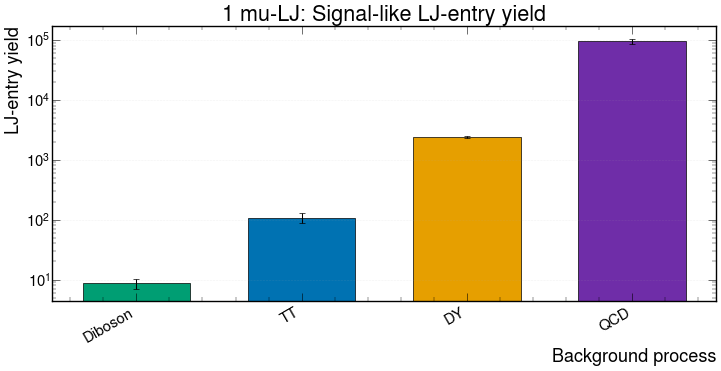

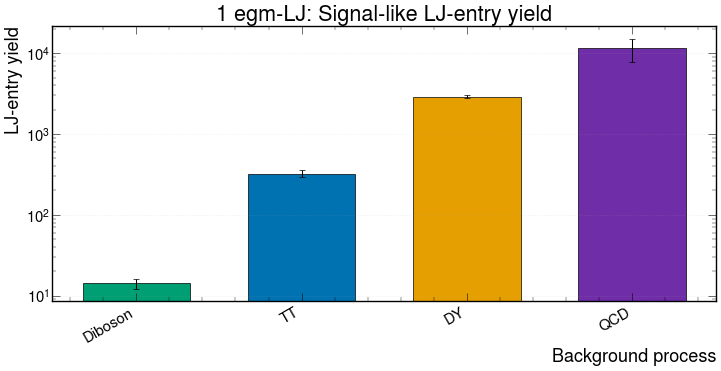

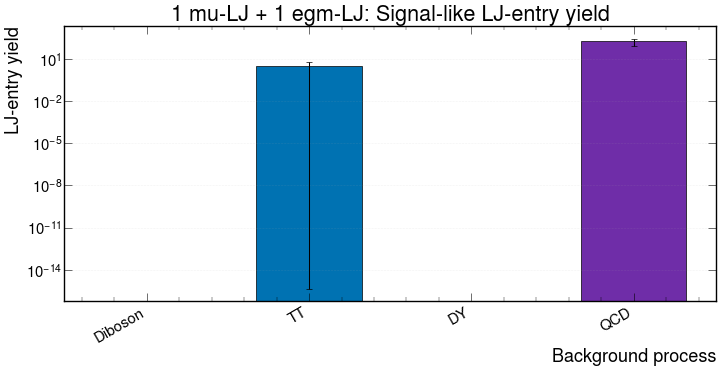

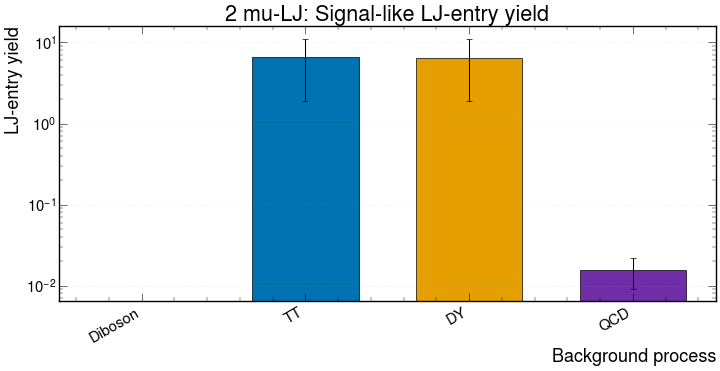

In [6]:
def plot_channel_yield(channel_label):
    table = channel_process_yields[channel_label]
    errors = channel_process_errors[channel_label]
    processes = list(BACKGROUND_GROUPS)
    x = np.arange(len(processes))
    values = table.loc["Signal-like", processes].to_numpy(float)
    uncertainty = errors.loc["Signal-like", processes].to_numpy(float)
    fig, ax = plt.subplots(figsize=(15, 8))
    colors = [GROUP_COLORS[process] for process in processes]
    ax.bar(x, values, color=colors, edgecolor="black", width=0.65)
    visible = values > 0
    ax.errorbar(x[visible], values[visible], yerr=uncertainty[visible], fmt="none", ecolor="black", capsize=4)
    ax.set_yscale("log")
    ax.set(title=f"{channel_label}: Signal-like LJ-entry yield", ylabel="LJ-entry yield", xlabel="Background process")
    ax.set_xticks(x, processes, rotation=30, ha="right")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout(); plt.show(); plt.close(fig)

for channel_label in BASE_CHANNELS:
    plot_channel_yield(channel_label)


## Signal-like background-process composition

Only fractions are plotted here. Yield information is already contained in the Signal-like panels above.

,Diboson,TT,DY,QCD
channel,,,,
1 mu-LJ — Signal-like,0.01,0.11,2.43,97.45
1 egm-LJ — Signal-like,0.10,2.19,19.63,78.08
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,1.76,0.00,98.24
2 mu-LJ — Signal-like,0.00,50.14,49.74,0.12


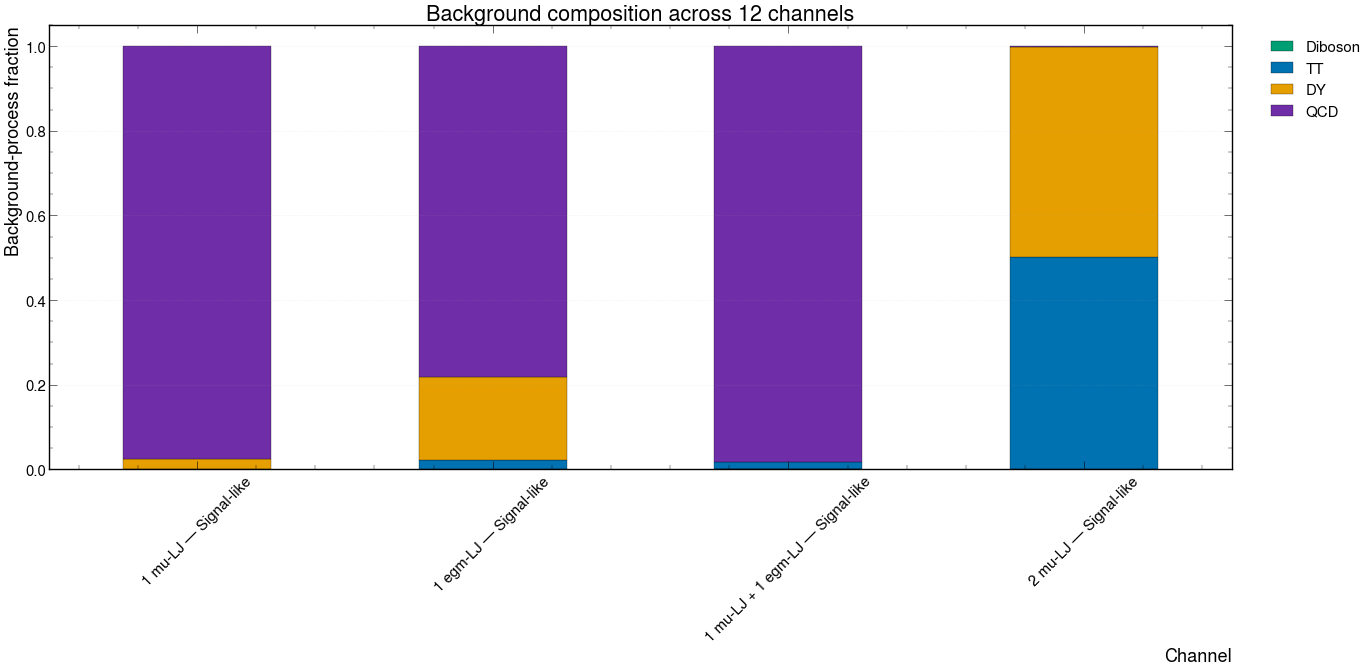

In [7]:
process_fraction_rows = []
for channel_label in BASE_CHANNELS:
    for region in REGION_SUFFIX:
        yields = channel_process_yields[channel_label].loc[region]
        total = yields.sum()
        row = {"channel": f"{channel_label} — {region}"}
        for process in BACKGROUND_GROUPS:
            row[process] = yields[process] / total if total > 0 else 0.0
        process_fraction_rows.append(row)
process_fraction_table = pd.DataFrame(process_fraction_rows).set_index("channel")
display((100 * process_fraction_table).round(2))
ax = process_fraction_table.plot(
    kind="bar", stacked=True, figsize=(28, 14),
    color=[GROUP_COLORS[p] for p in process_fraction_table.columns],
    edgecolor="black", linewidth=0.4,
)
ax.set(xlabel="Channel", ylabel="Background-process fraction", title="Background composition across 12 channels")
ax.tick_params(axis="x", rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.grid(axis="y", linestyle=":", alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

## Generator-mother composition

In [8]:
MOTHER_CATEGORY_ORDER = [
    "Z", "W", "e", "Muon", r"$\pi$", r"$\eta$/$\omega$",
    "B Meson", "D Meson", "Quark/Gluon", r"J/$\Psi$", "Others",
]
MOTHER_COLORS = {
    "Z": "#0072B2", "W": "#E69F00", "e": "#CC79A7", "Muon": "#17BECF",
    r"$\pi$": "#009E73", r"$\eta$/$\omega$": "#56B4E9",
    "B Meson": "#D55E00", "D Meson": "#F0E442",
    "Quark/Gluon": "#6F2DA8", r"J/$\Psi$": "#8C564B", "Others": "#7F7F7F",
}
MOTHER_HISTOGRAMS = {
    "All matched objects": "fs_gen_mother_id",
    "Electron": "fs_e_gen_mother_id",
    "Muon": "fs_mu_gen_mother_id",
    "Photon": "fs_pho_gen_mother_id",
}

def categorize_background_mother(pdgid):
    abs_id = abs(int(pdgid))
    if abs_id == 23: return "Z"
    if abs_id == 24: return "W"
    if abs_id == 11: return "e"
    if abs_id == 13: return "Muon"
    if abs_id in (111, 211): return r"$\pi$"
    if abs_id in (221, 223): return r"$\eta$/$\omega$"
    if abs_id in (511, 521, 531, 541): return "B Meson"
    if abs_id in (411, 421, 423, 431): return "D Meson"
    if abs_id in (1, 2, 3, 4, 5, 6, 9, 21): return "Quark/Gluon"
    if abs_id == 443: return r"J/$\Psi$"
    return "Others"


def categorize_mother_histogram(histogram):
    flow_values = np.asarray(histogram.values(flow=True), dtype=float)
    flow_variances = histogram.variances(flow=True)
    flow_variances = np.abs(flow_values) if flow_variances is None else np.asarray(flow_variances, dtype=float)
    centers = np.asarray(histogram.axes[0].centers, dtype=int)
    yields = defaultdict(float)
    variances = defaultdict(float)
    for pdgid, value, variance in zip(centers, flow_values[1:-1], flow_variances[1:-1]):
        category = categorize_background_mother(pdgid)
        yields[category] += float(value)
        variances[category] += float(variance)
    yields["Others"] += float(flow_values[0] + flow_values[-1])
    variances["Others"] += float(flow_variances[0] + flow_variances[-1])
    return yields, variances


def mother_category_table(samples, channel, histogram_name):
    histogram, _ = sum_histogram(samples, channel, histogram_name)
    yields, variances = categorize_mother_histogram(histogram)
    return (
        pd.Series(yields).reindex(MOTHER_CATEGORY_ORDER, fill_value=0.0),
        np.sqrt(pd.Series(variances).reindex(MOTHER_CATEGORY_ORDER, fill_value=0.0)),
    )

### Common mother order (lowest total yield first)

,mother-object yield
e,125.656485
W,456.405796
Z,3371.778530
Muon,6818.699567
$\eta$/$\omega$,7903.187844
J/$\Psi$,19898.306234
Others,48553.201909
B Meson,87126.259515
D Meson,90766.738102
$\pi$,92655.662651


### All matched objects: mother composition (%)

,e,W,Z,Muon,$\eta$/$\omega$,J/$\Psi$,Others,B Meson,D Meson,$\pi$,Quark/Gluon
channel,,,,,,,,,,,
1 mu-LJ — Signal-like,0.00,0.02,0.54,0.41,1.20,3.16,10.34,18.46,19.28,13.99,32.61
1 egm-LJ — Signal-like,0.31,0.78,0.10,10.60,1.13,0.00,2.09,1.96,1.05,61.93,20.05
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.33,0.00,0.00,0.76,14.54,3.93,24.80,20.59,31.60,3.45
2 mu-LJ — Signal-like,0.03,40.08,39.76,20.04,0.00,0.00,0.05,0.00,0.00,0.05,0.00


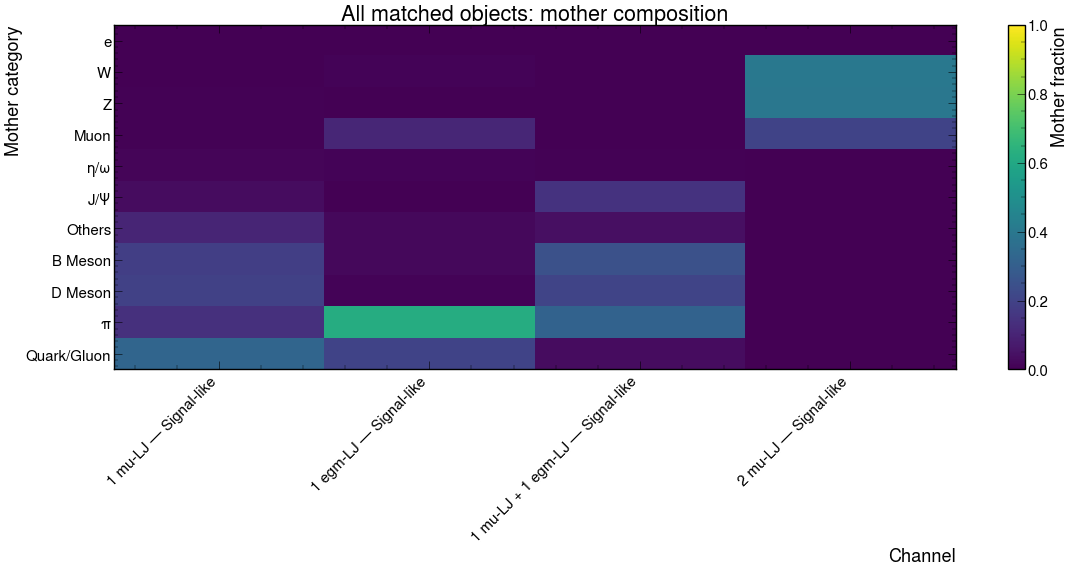

### Electron: mother composition (%)

,e,W,Z,Muon,$\eta$/$\omega$,J/$\Psi$,Others,B Meson,D Meson,$\pi$,Quark/Gluon
channel,,,,,,,,,,,
1 mu-LJ — Signal-like,0.0,0.00,0.00,0.11,0.77,0.0,10.62,5.98,6.57,8.97,66.98
1 egm-LJ — Signal-like,0.0,29.69,0.06,0.00,4.21,0.0,6.32,26.73,6.26,7.36,19.37
1 mu-LJ + 1 egm-LJ — Signal-like,0.0,0.00,0.00,0.00,0.00,0.0,0.00,44.94,45.72,0.00,9.33
2 mu-LJ — Signal-like,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00


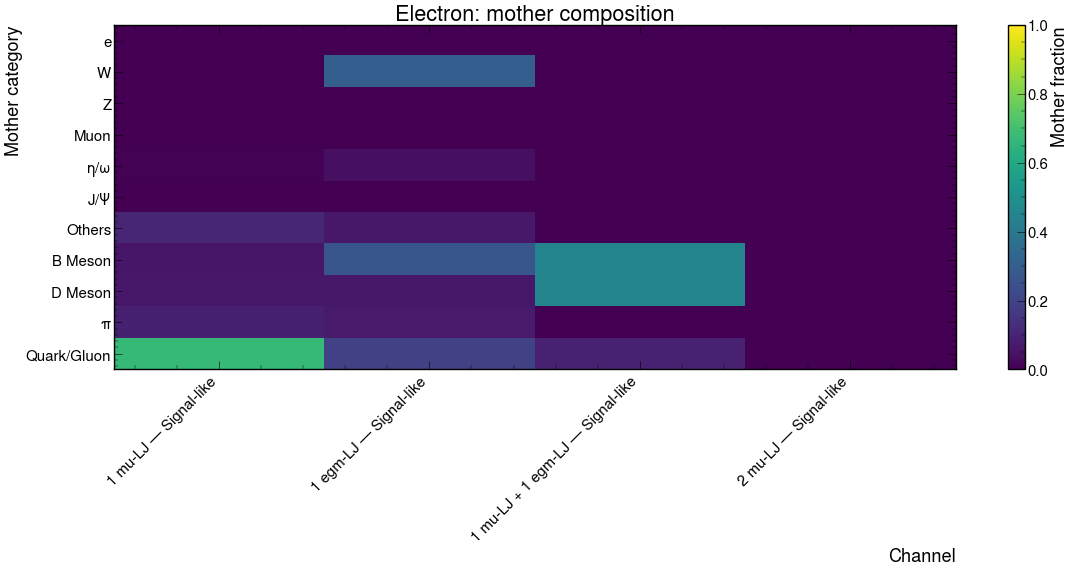

### Muon: mother composition (%)

,e,W,Z,Muon,$\eta$/$\omega$,J/$\Psi$,Others,B Meson,D Meson,$\pi$,Quark/Gluon
channel,,,,,,,,,,,
1 mu-LJ — Signal-like,0.00,0.04,1.02,0.0,1.38,6.00,9.05,17.51,18.29,12.72,34.00
1 egm-LJ — Signal-like,0.00,0.49,0.99,0.0,0.00,0.00,8.43,3.50,4.59,78.46,3.54
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,1.39,0.00,0.0,0.00,60.29,3.56,19.96,10.68,3.55,0.57
2 mu-LJ — Signal-like,0.02,50.16,49.76,0.0,0.00,0.00,0.02,0.00,0.00,0.04,0.00


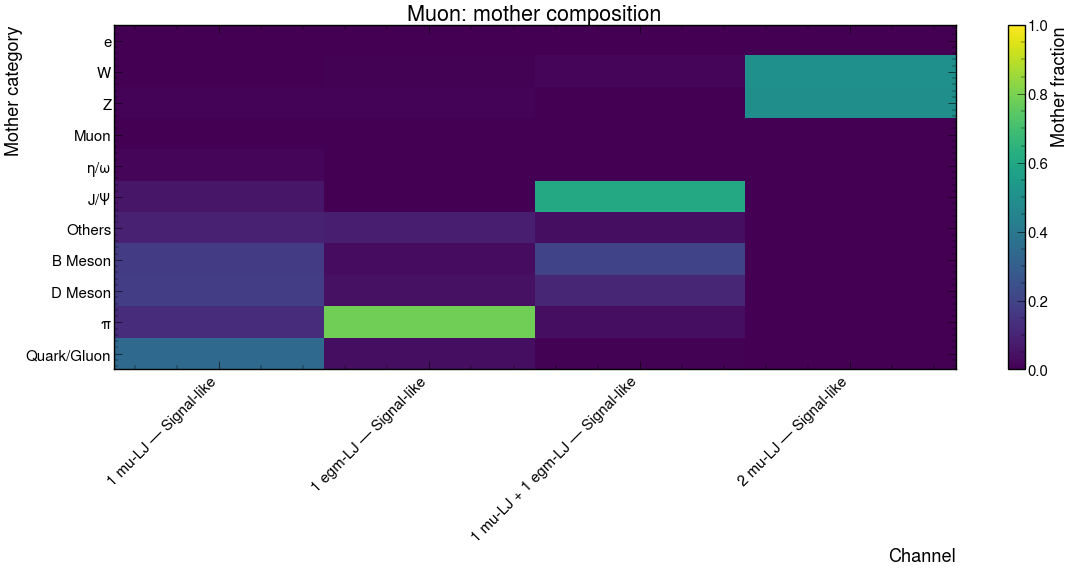

### Photon: mother composition (%)

,e,W,Z,Muon,$\eta$/$\omega$,J/$\Psi$,Others,B Meson,D Meson,$\pi$,Quark/Gluon
channel,,,,,,,,,,,
1 mu-LJ — Signal-like,0.00,0.03,0.0,10.26,12.20,0.0,3.24,0.0,0.55,65.22,8.51
1 egm-LJ — Signal-like,0.52,0.31,0.0,17.83,1.79,0.0,0.18,0.0,0.00,46.79,32.58
1 mu-LJ + 1 egm-LJ — Signal-like,0.00,0.00,0.0,0.00,8.79,0.0,0.15,0.0,0.00,70.10,20.96
2 mu-LJ — Signal-like,0.00,0.00,0.0,100.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00


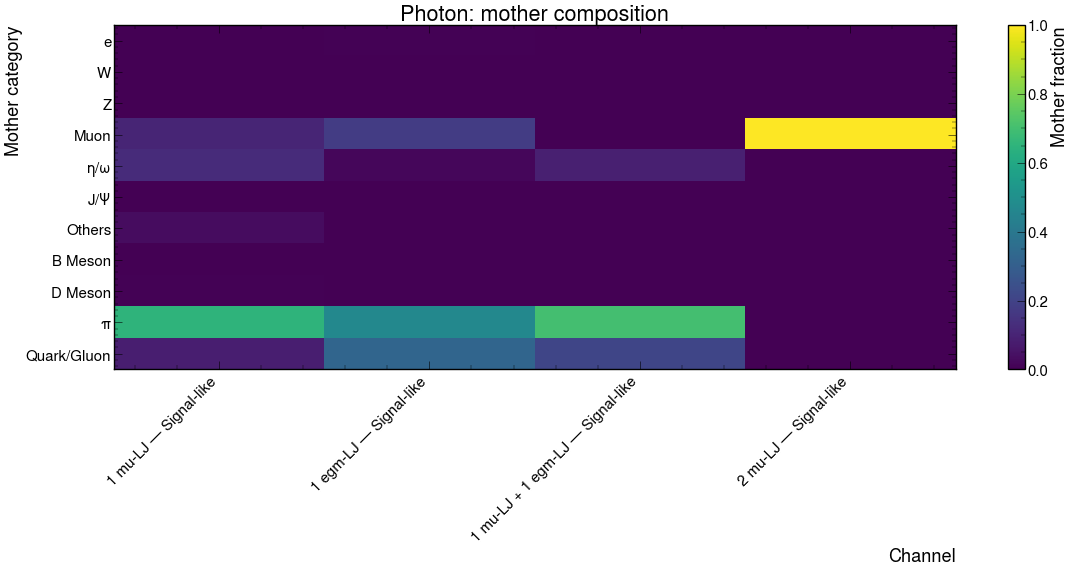

In [9]:
mother_fraction_tables = {}
global_mother_yield = pd.Series(0.0, index=MOTHER_CATEGORY_ORDER)
for object_label, histogram_name in MOTHER_HISTOGRAMS.items():
    rows = []
    for channel_label in BASE_CHANNELS:
        for region in REGION_SUFFIX:
            series, _ = mother_category_table(SAMPLES, channel_name(channel_label, region), histogram_name)
            total = series.sum()
            rows.append({"channel": f"{channel_label} — {region}", **(series / total if total > 0 else series * 0)})
            global_mother_yield = global_mother_yield.add(series, fill_value=0.0)
    mother_fraction_tables[object_label] = pd.DataFrame(rows).set_index("channel").reindex(columns=MOTHER_CATEGORY_ORDER)

MOTHER_STACK_ORDER = global_mother_yield.sort_values(kind="stable").index.tolist()
display(Markdown("### Common mother order (lowest total yield first)"))
display(global_mother_yield.reindex(MOTHER_STACK_ORDER).rename("mother-object yield").to_frame())

for object_label, table in mother_fraction_tables.items():
    table = table.reindex(columns=MOTHER_STACK_ORDER)
    mother_fraction_tables[object_label] = table
    display(Markdown(f"### {object_label}: mother composition (%)"))
    display((100 * table).round(2))
    fig, ax = plt.subplots(figsize=(24, 12))
    image = ax.imshow(table.T.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(len(table.index)), table.index, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.columns)), table.columns)
    ax.set(title=f"{object_label}: mother composition", xlabel="Channel", ylabel="Mother category")
    fig.colorbar(image, ax=ax, label="Mother fraction")
    plt.tight_layout(); plt.show(); plt.close(fig)

## Signal-like process-resolved mother yield

Each panel shows the Signal-like mother-object yield resolved by background process.

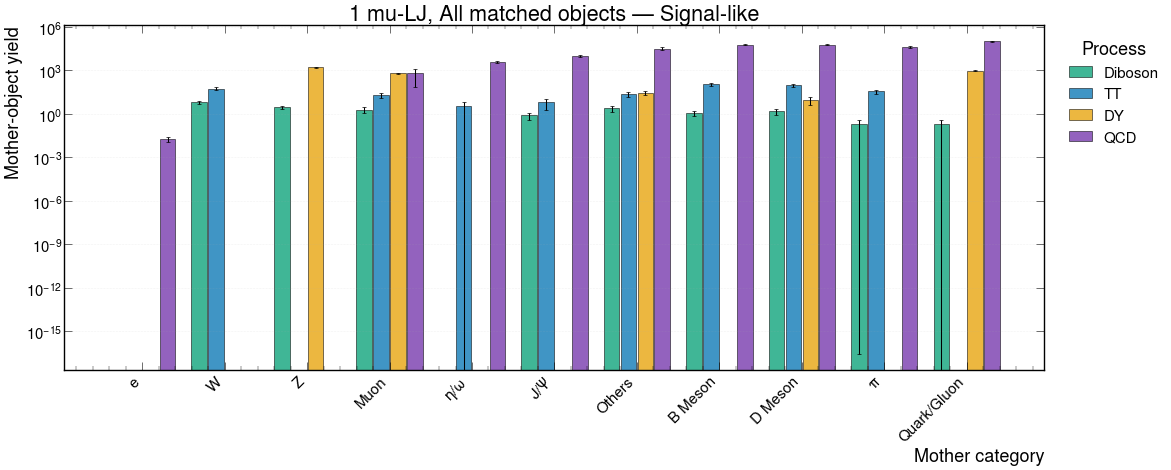

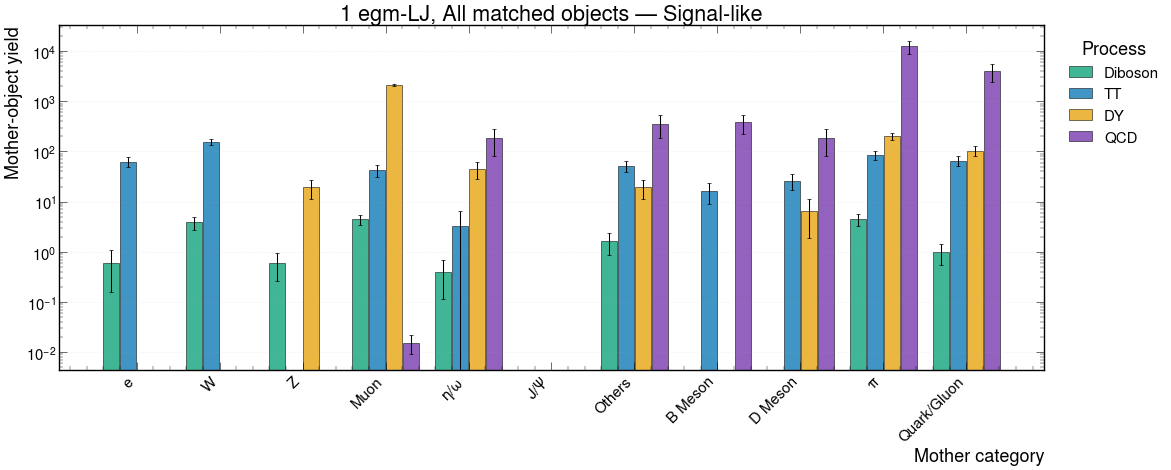

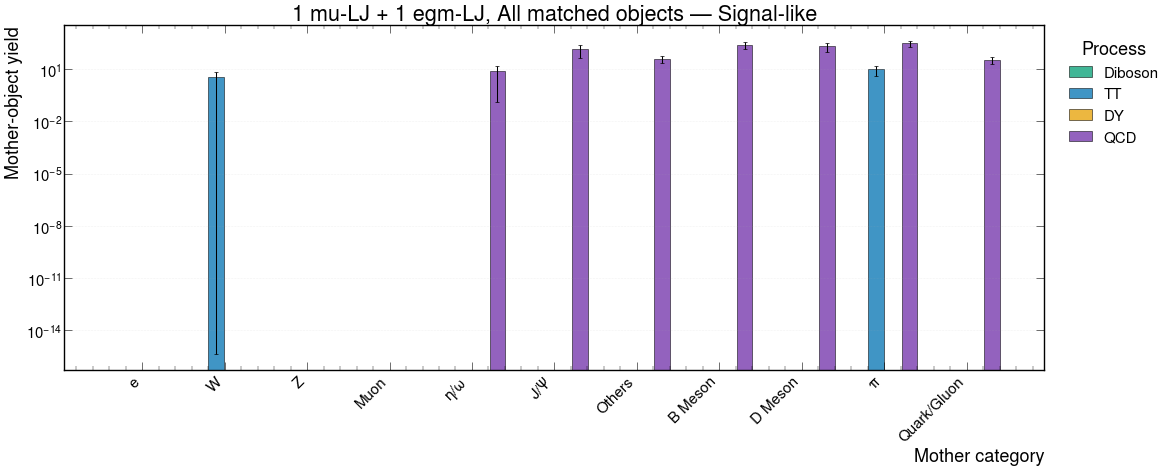

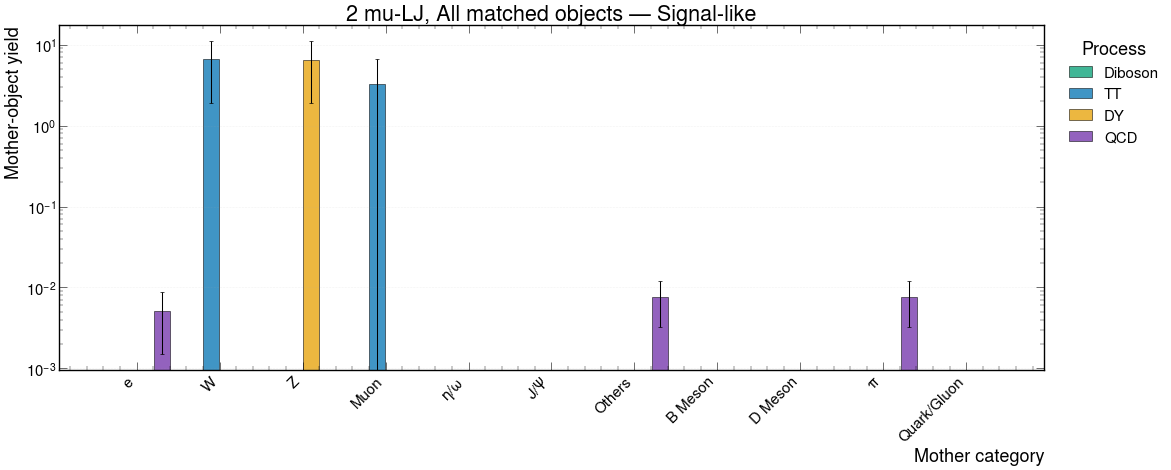

In [10]:
def process_mother_table(channel_label, histogram_name):
    yield_rows = {}
    error_rows = {}
    for group, samples in BACKGROUND_GROUPS.items():
        series, error = mother_category_table(
            samples, channel_name(channel_label, "Signal-like"), histogram_name
        )
        yield_rows[group] = series
        error_rows[group] = error
    return (
        pd.DataFrame(yield_rows).T.reindex(columns=MOTHER_STACK_ORDER),
        pd.DataFrame(error_rows).T.reindex(columns=MOTHER_STACK_ORDER),
    )


def plot_process_mother_signal_like(channel_label, object_label, histogram_name):
    table, errors = process_mother_table(channel_label, histogram_name)
    processes = list(BACKGROUND_GROUPS)
    categories = MOTHER_STACK_ORDER
    x = np.arange(len(categories))
    width = 0.82 / len(processes)
    offsets = (np.arange(len(processes)) - (len(processes) - 1) / 2) * width
    fig, ax = plt.subplots(figsize=(24, 10))
    for index, process in enumerate(processes):
        positions = x + offsets[index]
        values = table.loc[process].to_numpy(float)
        uncertainty = errors.loc[process].to_numpy(float)
        ax.bar(positions, values, width=0.92 * width, color=GROUP_COLORS[process], edgecolor="black", alpha=0.75, label=process)
        visible = values > 0
        ax.errorbar(positions[visible], values[visible], yerr=uncertainty[visible], fmt="none", ecolor="black", capsize=3)
    ax.set_yscale("log")
    ax.set(title=f"{channel_label}, {object_label} — Signal-like", ylabel="Mother-object yield", xlabel="Mother category")
    ax.set_xticks(x, categories, rotation=45, ha="right")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    ax.legend(title="Process", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(); plt.show(); plt.close(fig)
    return table, errors


mother_overlay_tables = {}
for channel_label in BASE_CHANNELS:
    mother_overlay_tables[channel_label] = plot_process_mother_signal_like(
        channel_label, "All matched objects", "fs_gen_mother_id"
    )


## 1-LJ vs 2-LJ kinematics

All-background normalized shapes compare the compatible 1-LJ and 2-LJ topologies. Error bars include histogram variances. Underflow and overflow are folded into the visible edge bins before normalization.

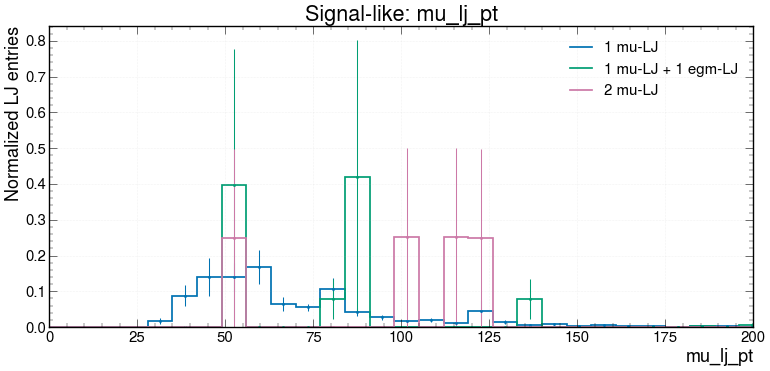

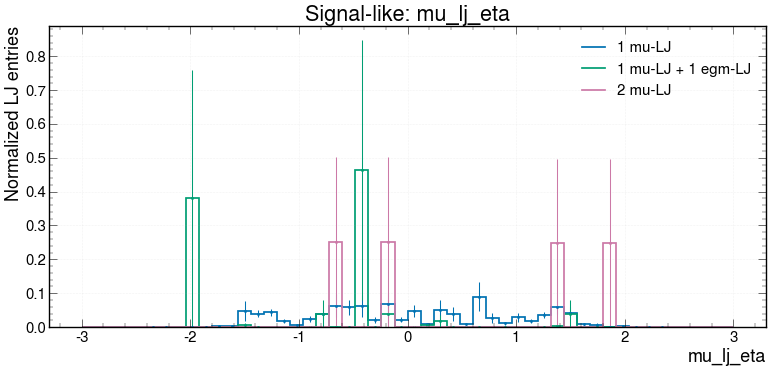

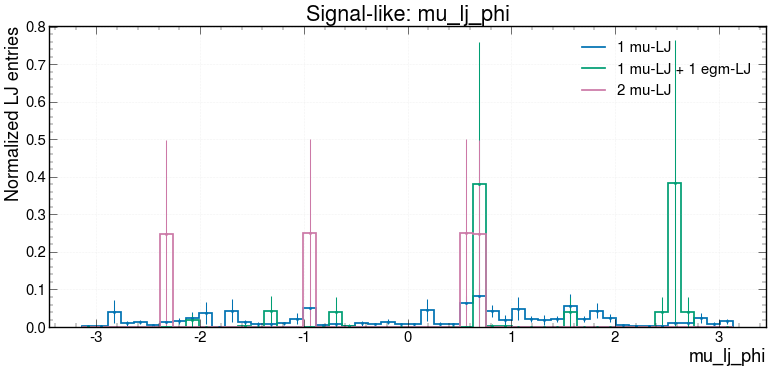

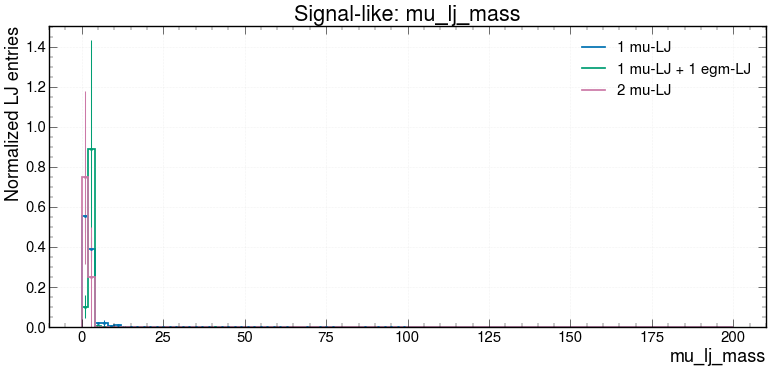

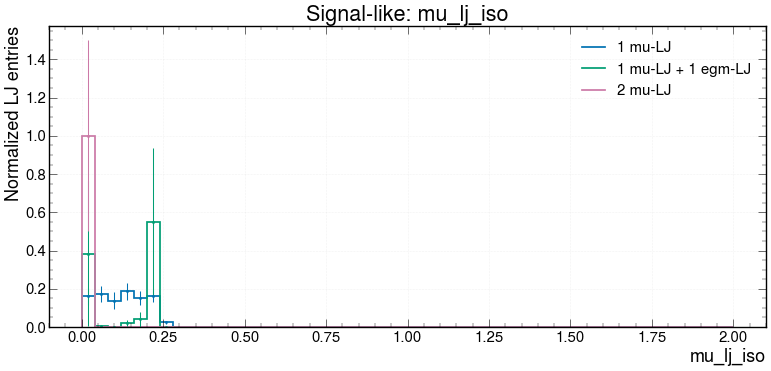

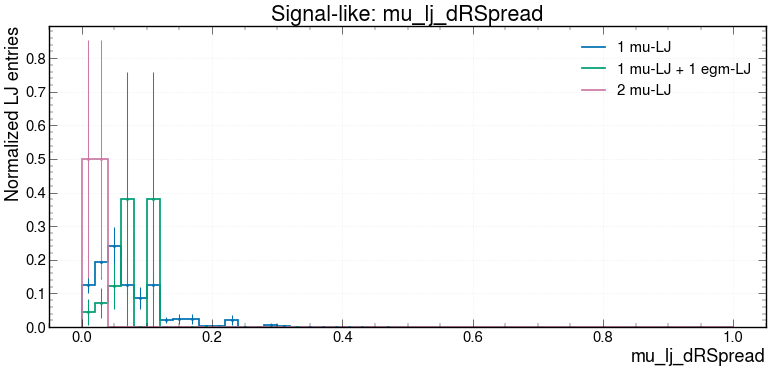

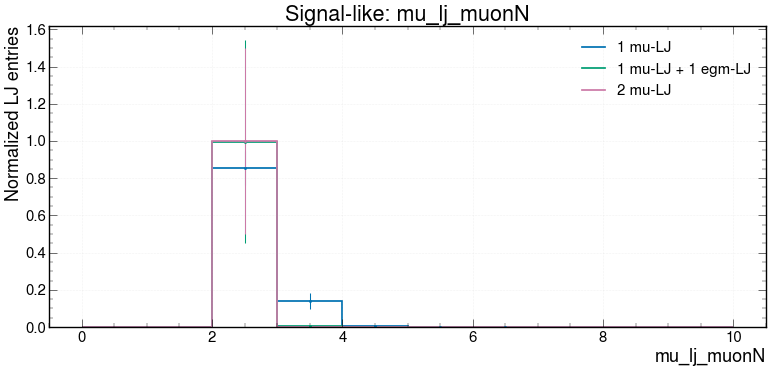

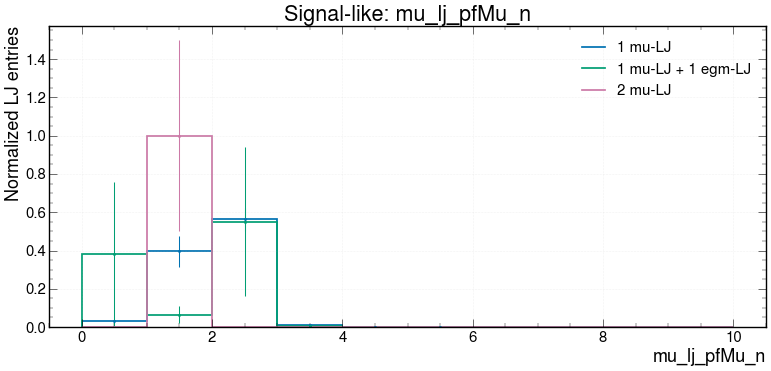

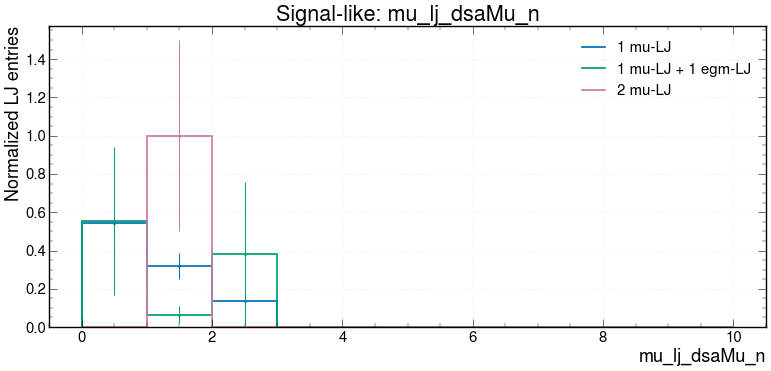

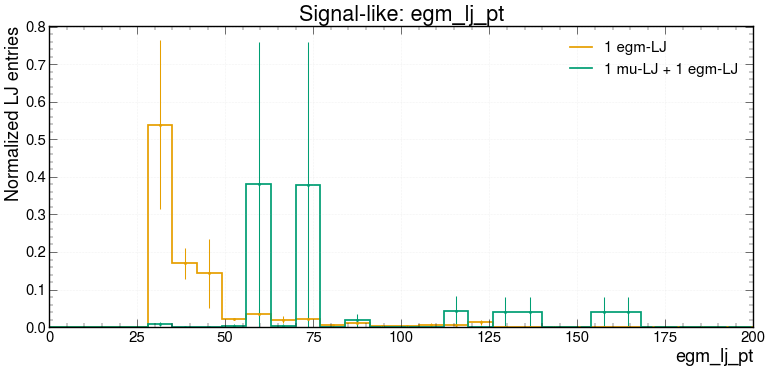

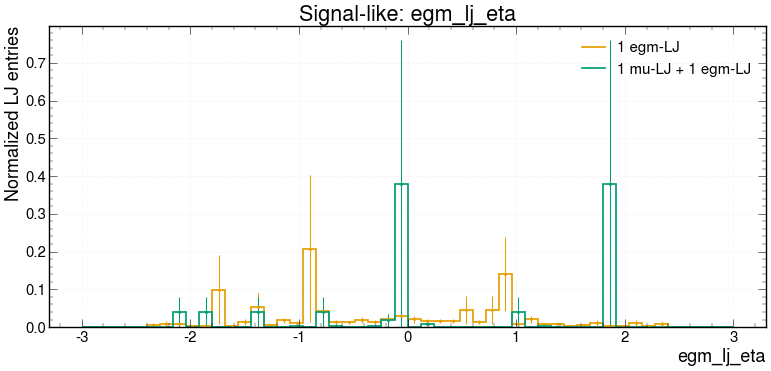

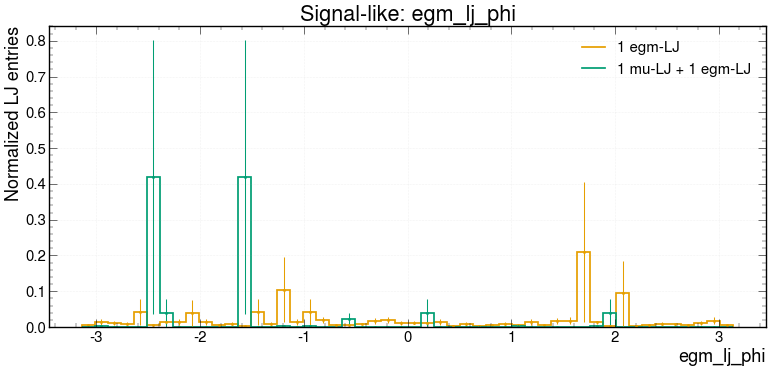

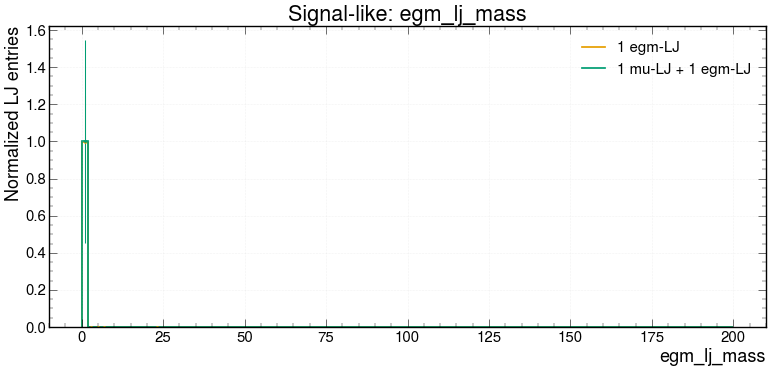

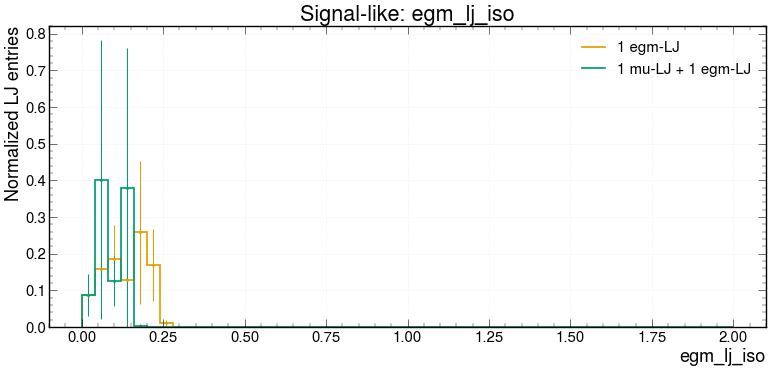

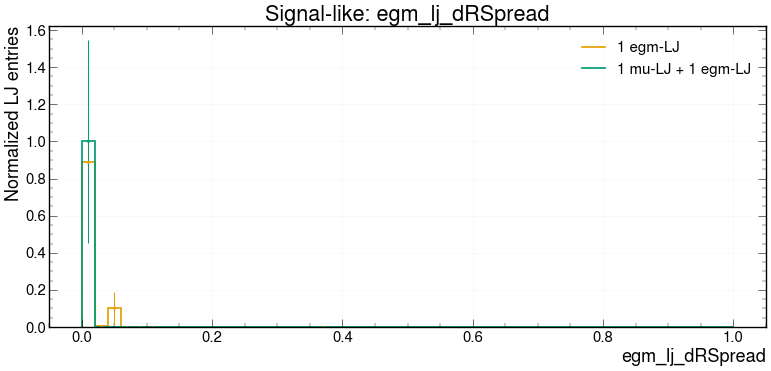

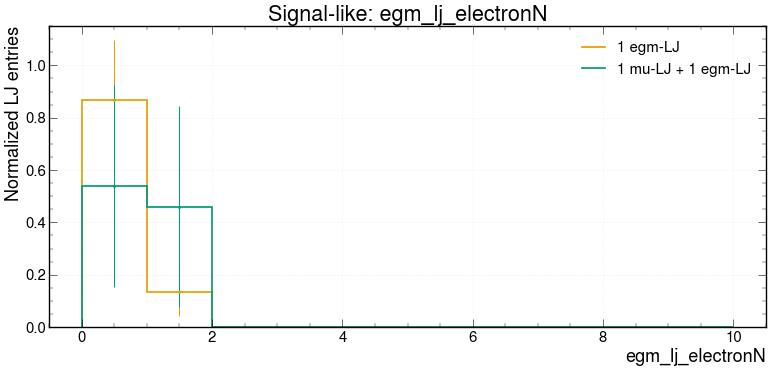

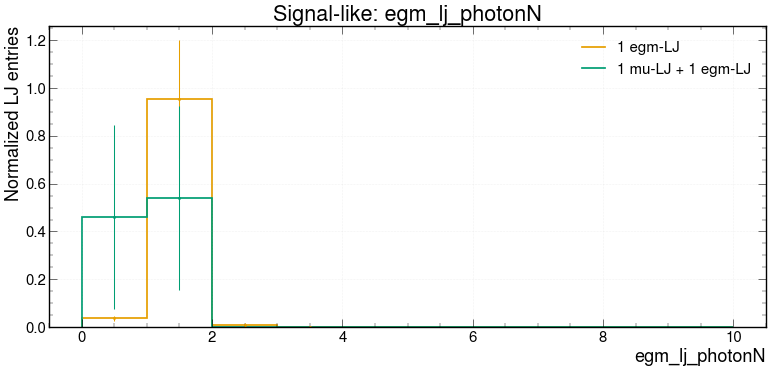

In [11]:
MU_VARIABLES = [
    "mu_lj_pt", "mu_lj_eta", "mu_lj_phi", "mu_lj_mass", "mu_lj_iso",
    "mu_lj_dRSpread", "mu_lj_muonN", "mu_lj_pfMu_n", "mu_lj_dsaMu_n",
]
EGM_VARIABLES = [
    "egm_lj_pt", "egm_lj_eta", "egm_lj_phi", "egm_lj_mass", "egm_lj_iso",
    "egm_lj_dRSpread", "egm_lj_electronN", "egm_lj_photonN",
]
VARIABLE_CHANNELS = {
    **{variable: ["1 mu-LJ", "1 mu-LJ + 1 egm-LJ", "2 mu-LJ"] for variable in MU_VARIABLES},
    **{variable: ["1 egm-LJ", "1 mu-LJ + 1 egm-LJ"] for variable in EGM_VARIABLES},
}
PLOT_OPTIONS = {
    "mu_lj_pt": {"xlim": (0, 200)}, "egm_lj_pt": {"xlim": (0, 200)},
    "mu_lj_mass_small": {"xlim": (0, 6)}, "egm_lj_mass_small": {"xlim": (0, 6)},
    "mu_lj_dRSpread": {"rebin": 5}, "egm_lj_dRSpread": {"rebin": 5},
}

def finish_shape_axis(ax, xlabel, title, xlim=None):
    ax.set(xlabel=xlabel, ylabel="Normalized LJ entries", title=title)
    if xlim is not None: ax.set_xlim(*xlim)
    ax.grid(linestyle=":", alpha=0.3)
    ax.legend(frameon=False)


def plot_channel_shapes(variable, region="Signal-like", rebin=1, xlim=None):
    fig, ax = plt.subplots(figsize=(16, 8))
    for channel_label in VARIABLE_CHANNELS[variable]:
        histogram, _ = sum_histogram(SAMPLES, channel_name(channel_label, region), variable)
        edges, shape, error = normalized_shape(histogram, rebin=rebin)
        color = CHANNEL_COLORS[channel_label]
        ax.stairs(shape, edges, label=channel_label, color=color, linewidth=2.5)
        centers = 0.5 * (edges[:-1] + edges[1:])
        visible = shape > 0
        ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
    finish_shape_axis(ax, variable, f"{region}: {variable}", xlim=xlim)
    plt.tight_layout(); plt.show(); plt.close(fig)

for variable in MU_VARIABLES + EGM_VARIABLES:
    plot_channel_shapes(variable, **PLOT_OPTIONS.get(variable, {}))

## Signal-like kinematics by channel

For each compatible channel, show the normalized shape after the Signal-like selection.

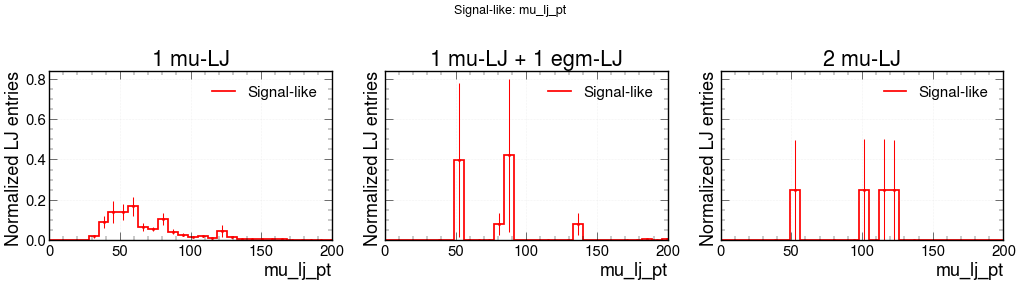

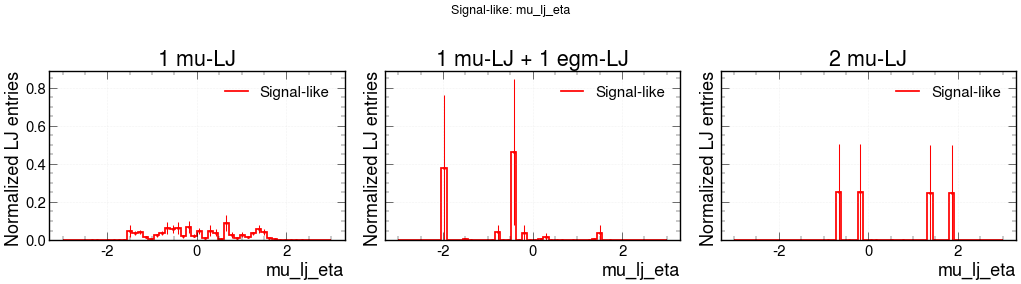

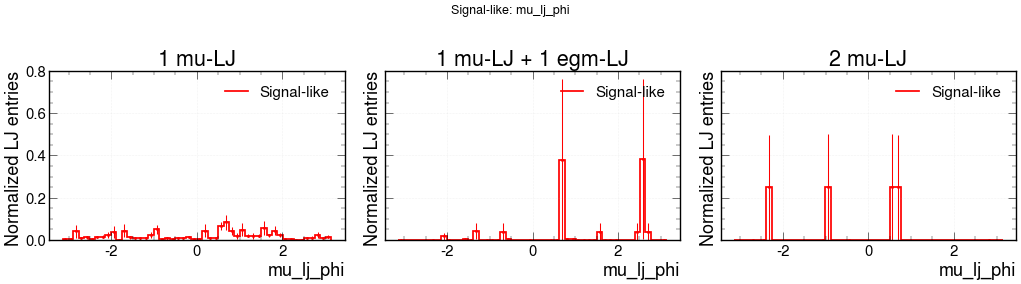

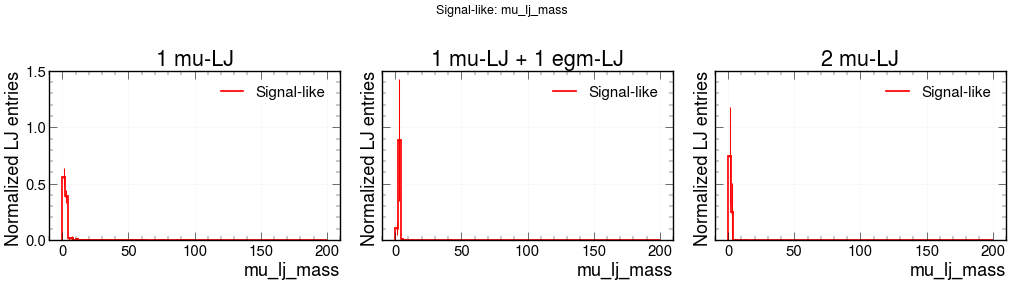

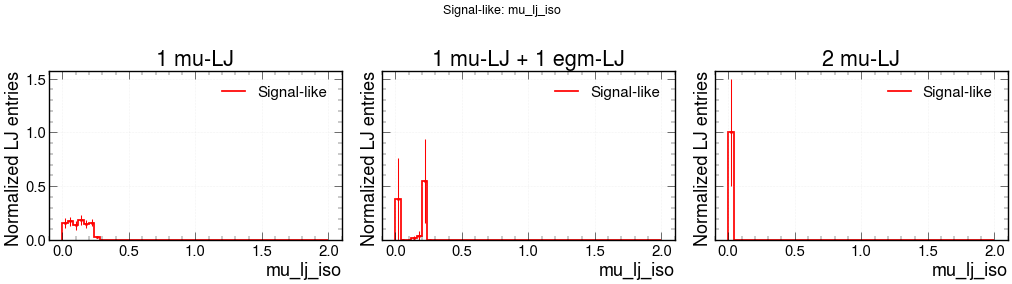

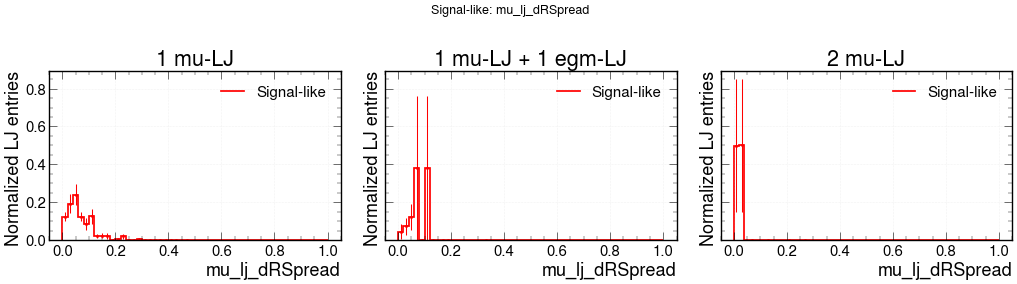

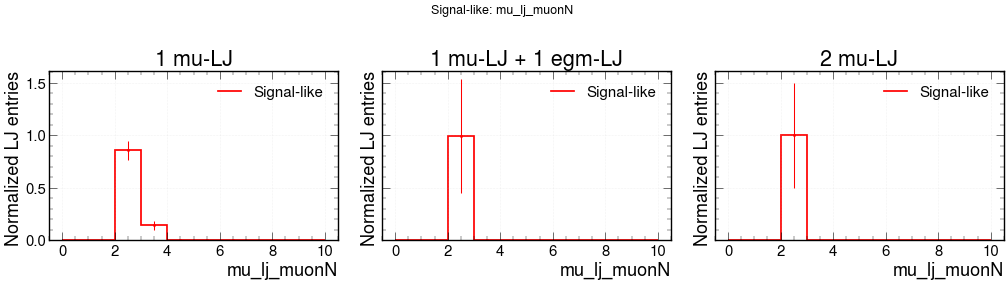

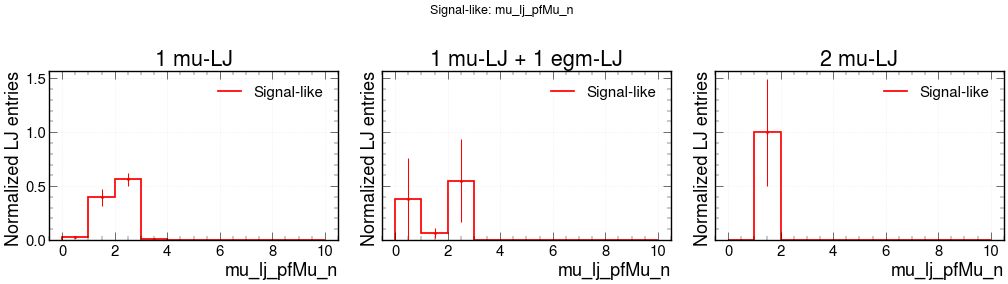

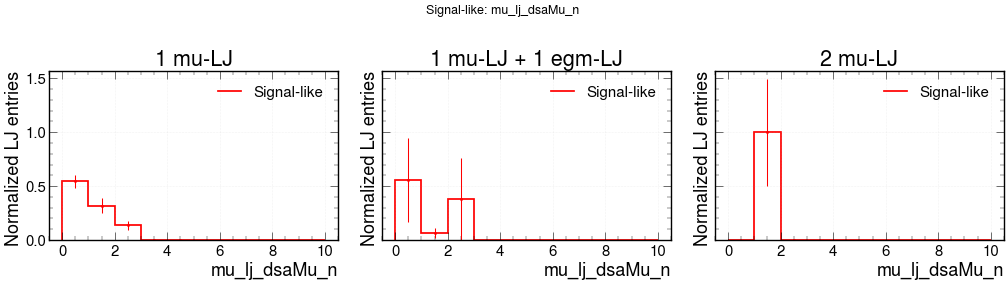

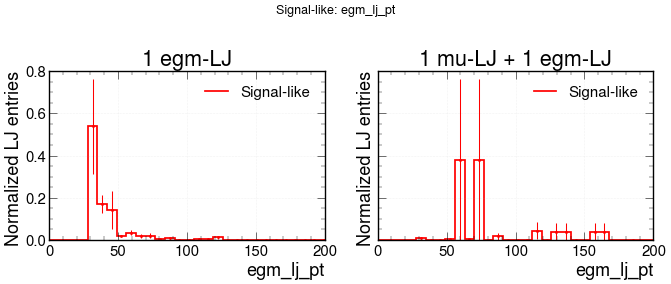

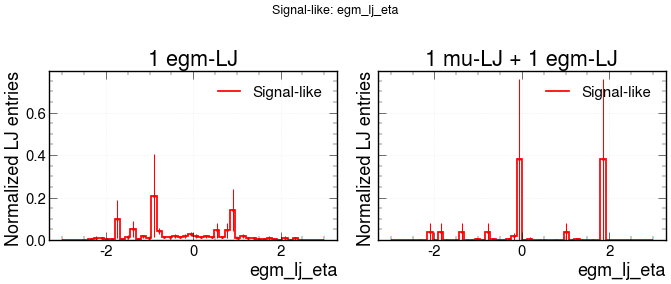

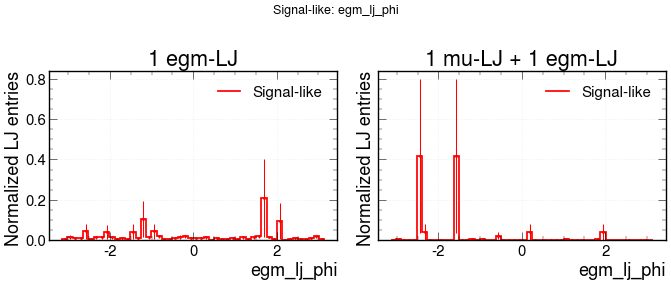

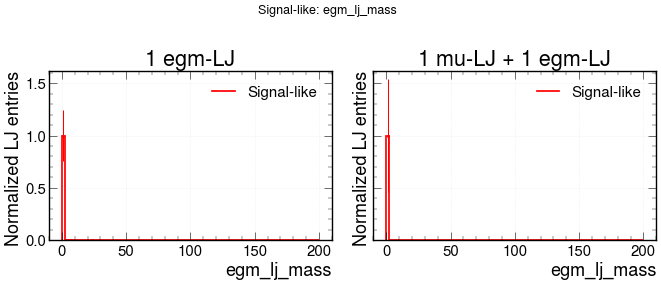

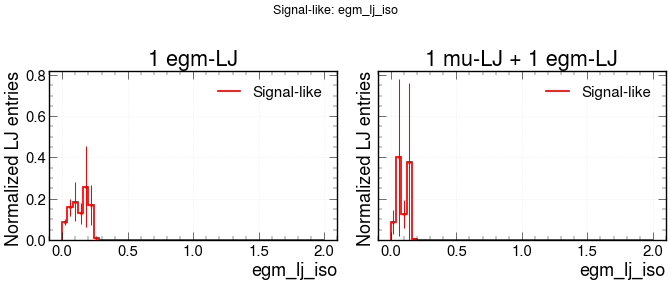

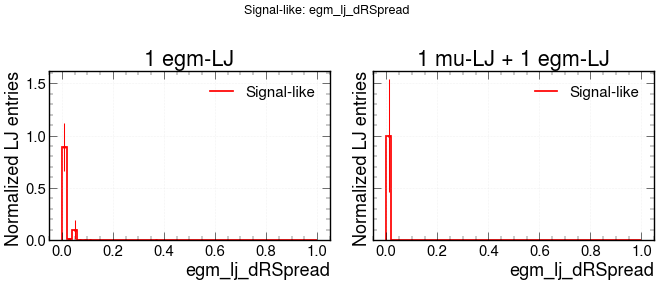

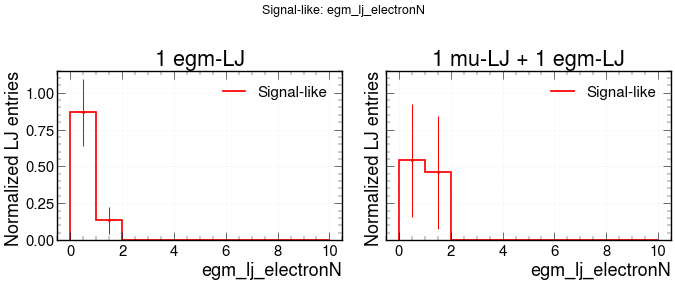

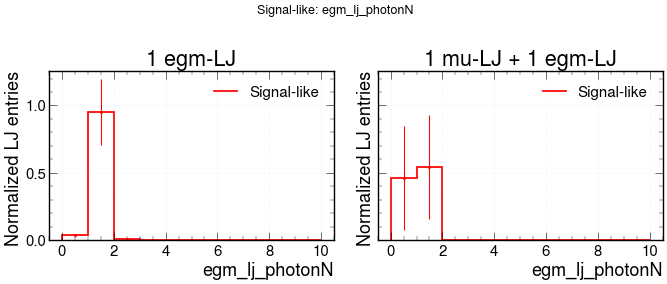

In [12]:
def plot_signal_like_shapes(variable, rebin=1, xlim=None):
    channels = VARIABLE_CHANNELS[variable]
    fig, axes = plt.subplots(1, len(channels), figsize=(7 * len(channels), 6), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, channel_label in zip(axes, channels):
        histogram, _ = sum_histogram(SAMPLES, channel_name(channel_label, "Signal-like"), variable)
        edges, shape, error = normalized_shape(histogram, rebin=rebin)
        color, linestyle = REGION_STYLES["Signal-like"]
        ax.stairs(shape, edges, label="Signal-like", color=color, linestyle=linestyle, linewidth=2.5)
        centers = 0.5 * (edges[:-1] + edges[1:])
        visible = shape > 0
        ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
        finish_shape_axis(ax, variable, channel_label, xlim=xlim)
    fig.suptitle(f"Signal-like: {variable}", fontsize=18)
    plt.tight_layout(); plt.show(); plt.close(fig)

for variable in MU_VARIABLES + EGM_VARIABLES:
    plot_signal_like_shapes(variable, **PLOT_OPTIONS.get(variable, {}))


## Optional process-separated kinematics

Set `RUN_PROCESS_SEPARATED_KINEMATICS = True` to produce the same Signal-like channel comparison for each background group. It is disabled by default to keep routine notebook execution compact.

In [13]:
RUN_PROCESS_SEPARATED_KINEMATICS = False

if RUN_PROCESS_SEPARATED_KINEMATICS:
    for group, samples in BACKGROUND_GROUPS.items():
        for variable in MU_VARIABLES + EGM_VARIABLES:
            options = PLOT_OPTIONS.get(variable, {})
            fig, ax = plt.subplots(figsize=(16, 8))
            for channel_label in VARIABLE_CHANNELS[variable]:
                histogram, _ = sum_histogram(samples, channel_name(channel_label, "Signal-like"), variable)
                edges, shape, error = normalized_shape(histogram, rebin=options.get("rebin", 1))
                color = CHANNEL_COLORS[channel_label]
                ax.stairs(shape, edges, label=channel_label, color=color, linewidth=2.5)
                centers = 0.5 * (edges[:-1] + edges[1:])
                visible = shape > 0
                ax.errorbar(centers[visible], shape[visible], yerr=error[visible], fmt="o", color=color, markersize=3)
            finish_shape_axis(ax, variable, f"{group}: Signal-like {variable}", xlim=options.get("xlim"))
            plt.tight_layout(); plt.show(); plt.close(fig)

## Compact summary

The table below collects the Signal-like yields for downstream comparison.

In [14]:
summary_rows = []
for channel_label in BASE_CHANNELS:
    yields = channel_process_yields[channel_label]
    errors = channel_process_errors[channel_label]
    for process in BACKGROUND_GROUPS:
        summary_rows.append({
            "channel": channel_label,
            "process": process,
            "signal_like_lj_entry_yield": yields.loc["Signal-like", process],
            "signal_like_uncertainty": errors.loc["Signal-like", process],
        })
lj_yield_summary = pd.DataFrame(summary_rows).set_index(["channel", "process"])
display(lj_yield_summary.round(5))


signal_like_lj_entry_yield  \
channel            process                               
1 mu-LJ            Diboson                     8.63204   
                   TT                        108.03061   
                   DY                       2374.12432   
                   QCD                     95101.95828   
1 egm-LJ           Diboson                    14.15158   
                   TT                        324.09182   
                   DY                       2899.68233   
                   QCD                     11535.73319   
1 mu-LJ + 1 egm-LJ Diboson                     0.00000   
                   TT                          3.27365   
                   DY                          0.00000   
                   QCD                       182.33223   
2 mu-LJ            Diboson                     0.00000   
                   TT                          6.54731   
                   DY                          6.49608   
                   QCD                         0.01543   

                            signal_like_uncertainty  
channel            process                           
1 mu-LJ            Diboson                  1.64523  
                   TT                      18.80572  
                   DY                     101.67230  
                   QCD                   9856.50478  
1 egm-LJ           Diboson                  2.01962  
                   TT                      32.57245  
                   DY                     102.43319  
                   QCD                   3652.39623  
1 mu-LJ + 1 egm-LJ Diboson                  0.00000  
                   TT                       3.27365  
                   DY                       0.00000  
                   QCD                    101.05079  
2 mu-LJ            Diboson                  0.00000  
                   TT                       4.62965  
                   DY                       4.59342  
                   QCD                      0.00630

## Large Signal-like mu-LJ eta and phi shapes

The standard loop above draws all kinematic variables compactly. The following
cell redraws only mu_lj_eta and mu_lj_phi at a larger size, using the same
Signal-like channels, normalization, and uncertainties.
The original histogram binning is preserved.


Saved: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/14_mu_lj_eta_siglike_shapes_large.png


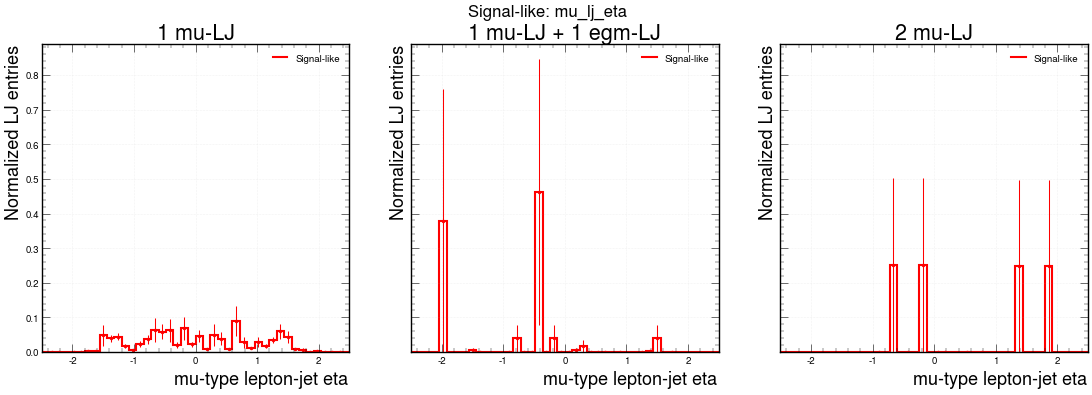

Saved: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/14_mu_lj_phi_siglike_shapes_large.png


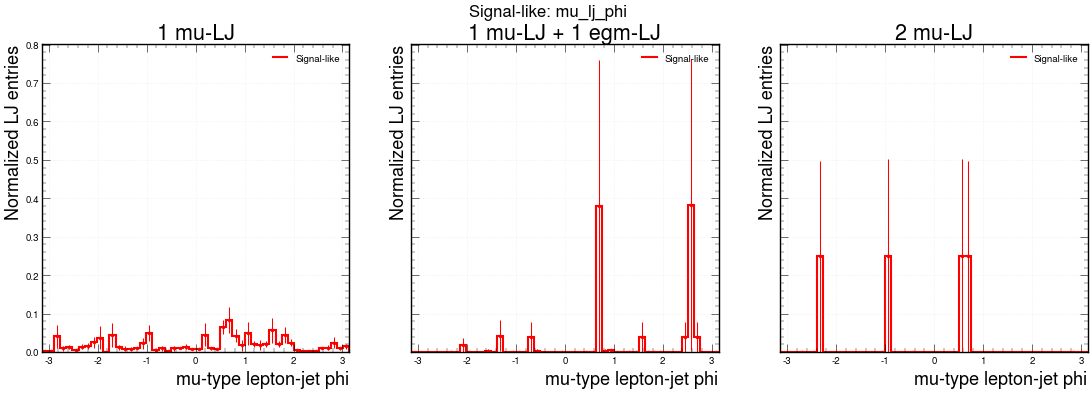

In [15]:
LARGE_MU_LJ_REGION_PLOTS = {
    "mu_lj_eta": {
        "xlim": (-2.5, 2.5),
        "xlabel": r"$mu$-type lepton-jet $eta$",
        "output": study_dir / "14_mu_lj_eta_siglike_shapes_large.png",
    },
    "mu_lj_phi": {
        "xlim": (-np.pi, np.pi),
        "xlabel": r"$mu$-type lepton-jet $phi$",
        "output": study_dir / "14_mu_lj_phi_siglike_shapes_large.png",
    },
}


def plot_large_mu_lj_signal_like_shapes(variable, xlim, xlabel, output):
    channels = VARIABLE_CHANNELS[variable]
    fig, axes = plt.subplots(
        1,
        len(channels),
        figsize=(9 * len(channels), 8),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, channel_label in zip(axes, channels):
        for region in ("Signal-like",):
            histogram, _ = sum_histogram(
                SAMPLES,
                channel_name(channel_label, region),
                variable,
            )
            edges, shape, error = normalized_shape(histogram, rebin=1)
            color, linestyle = REGION_STYLES[region]
            ax.stairs(
                shape,
                edges,
                label=region,
                color=color,
                linestyle=linestyle,
                linewidth=3,
            )
            centers = 0.5 * (edges[:-1] + edges[1:])
            visible = shape > 0
            ax.errorbar(
                centers[visible],
                shape[visible],
                yerr=error[visible],
                fmt="o",
                color=color,
                markersize=4,
            )

        ax.set(
            xlabel=xlabel,
            ylabel="Normalized LJ entries",
            title=channel_label,
            xlim=xlim,
        )
        ax.tick_params(axis="both", labelsize=14)
        ax.grid(linestyle=":", alpha=0.3)
        ax.legend(frameon=False, fontsize=14)

    fig.suptitle(
        f"Signal-like: {variable}",
        fontsize=24,
    )
    fig.savefig(output, dpi=180, bbox_inches="tight")
    print(f"Saved: {output}")
    plt.show()
    plt.close(fig)


for variable, options in LARGE_MU_LJ_REGION_PLOTS.items():
    plot_large_mu_lj_signal_like_shapes(variable, **options)


# Eta–Phi hotspot and pixel-veto cross-check

The available output contains eta–phi histograms but no missing-inner-hit multiplicity. These plots therefore test geometric compatibility and selection enrichment, not the detector-level cause itself. The reference rectangles follow the 2017 and 2018 regions used in notebook `10`.

In [16]:
ETA_PHI_HISTOGRAMS = {
    "Electron": "electron_eta_phi", "Muon": "muon_eta_phi",
    "Photon": "photon_eta_phi", "DSA muon": "dsaMuon_eta_phi",
    "mu-LJ": "mu_lj_eta_phi", "egm-LJ": "egm_lj_eta_phi",
}
VETO_REGIONS = {
    "2017": {"eta": (1.0, 1.5), "phi": (2.7, np.pi), "color": "red"},
    "2018": {"eta": (0.3, 1.2), "phi": (0.4, 0.8), "color": "magenta"},
}

missing_eta_phi = {
    sample: sorted(set(ETA_PHI_HISTOGRAMS.values()) - set(out[sample]["hists"]))
    for sample in SAMPLES
}
assert not any(missing_eta_phi.values()), f"Missing eta-phi histograms: {missing_eta_phi}"
print("All eta-phi histograms are available in the latest merged outputs.")

All eta-phi histograms are available in the latest merged outputs.


In [17]:
def sum_eta_phi_histogram(samples, channel, histogram_name):
    histogram, _ = sum_histogram(samples, channel, histogram_name)
    return histogram

def eta_phi_arrays(histogram):
    eta_axis, phi_axis = histogram.axes
    values = np.asarray(histogram.values(), dtype=float)
    variances = histogram.variances()
    variances = np.abs(values) if variances is None else np.asarray(variances, dtype=float)
    return np.asarray(eta_axis.edges), np.asarray(phi_axis.edges), values, variances

def draw_map(ax, histogram, title, mode="yield"):
    eta_edges, phi_edges, values, variances = eta_phi_arrays(histogram)
    if mode == "density":
        total = values.sum()
        shown = values / total if total > 0 else np.zeros_like(values)
        mesh = ax.pcolormesh(phi_edges, eta_edges, shown, cmap="viridis", shading="auto")
        label = "Fraction / bin"
    else:
        positive = values[values > 0]
        norm = LogNorm(vmin=max(positive.min(), positive.max()*1e-4), vmax=positive.max()) if positive.size else None
        mesh = ax.pcolormesh(phi_edges, eta_edges, np.clip(values, 0, None), cmap="viridis", norm=norm, shading="auto")
        label = "Weighted entries"
    ax.set(title=title, xlabel=r"$\phi$", ylabel=r"$\eta$", xlim=(-np.pi, np.pi))
    return mesh, label

def region_stats(histogram, spec):
    eta_edges, phi_edges, values, variances = eta_phi_arrays(histogram)
    eta = 0.5 * (eta_edges[:-1] + eta_edges[1:])
    phi = 0.5 * (phi_edges[:-1] + phi_edges[1:])
    mask = ((eta[:, None] >= spec["eta"][0]) & (eta[:, None] <= spec["eta"][1]) &
            (phi[None, :] >= spec["phi"][0]) & (phi[None, :] <= spec["phi"][1]))
    selected = float(values[mask].sum())
    variance = float(variances[mask].sum())
    total = float(values.sum())
    return selected, np.sqrt(max(variance, 0)), total, selected / total if total > 0 else np.nan


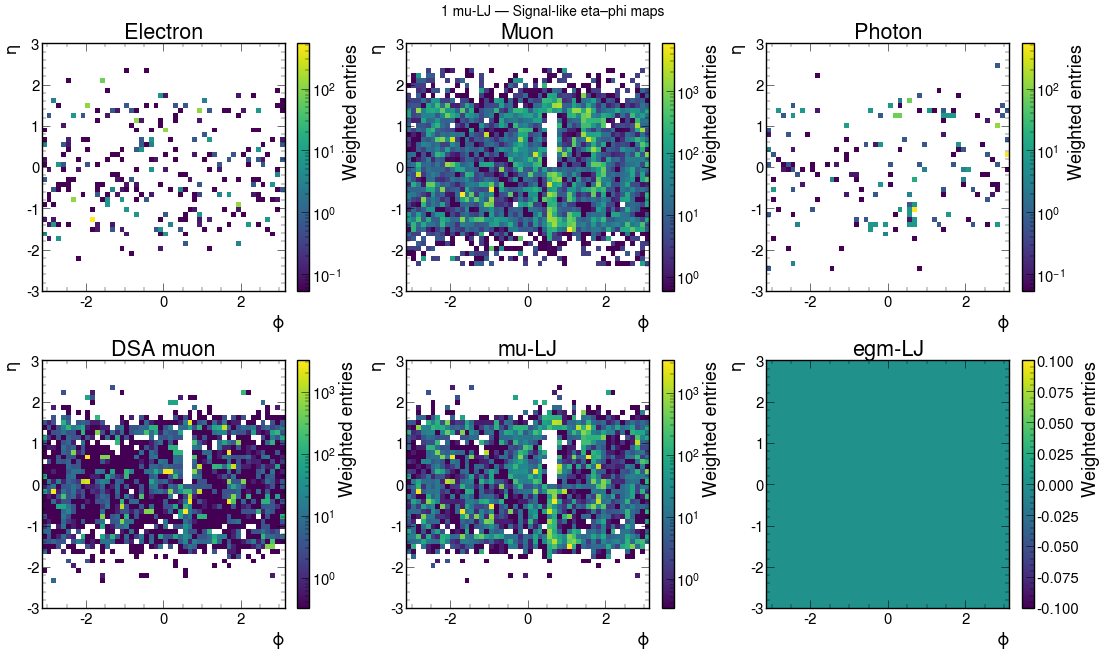

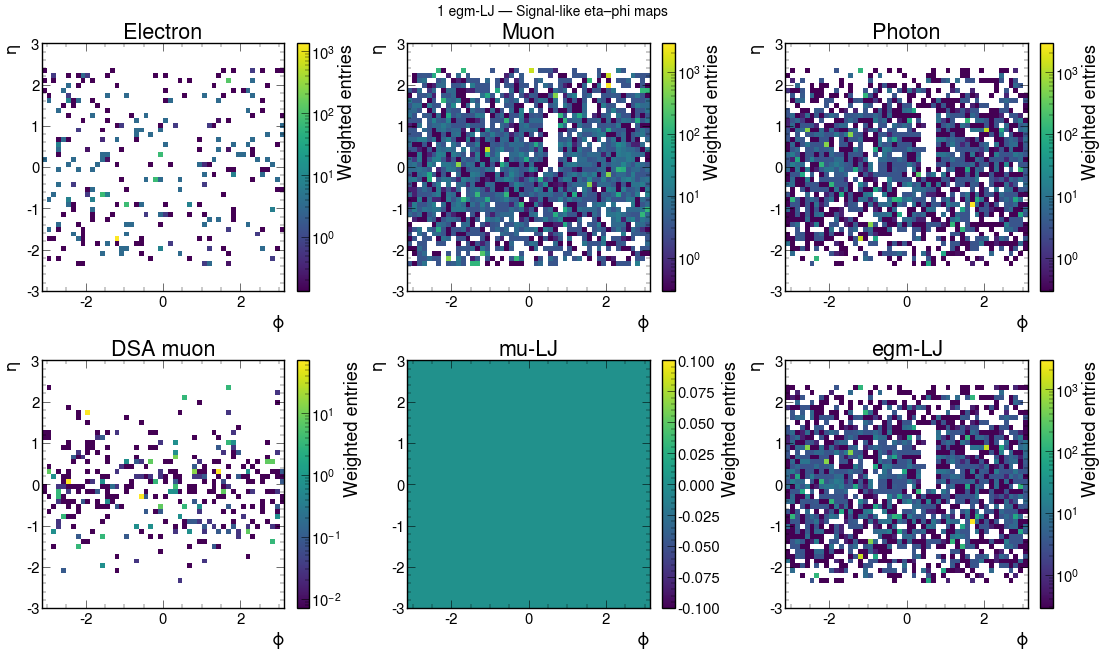

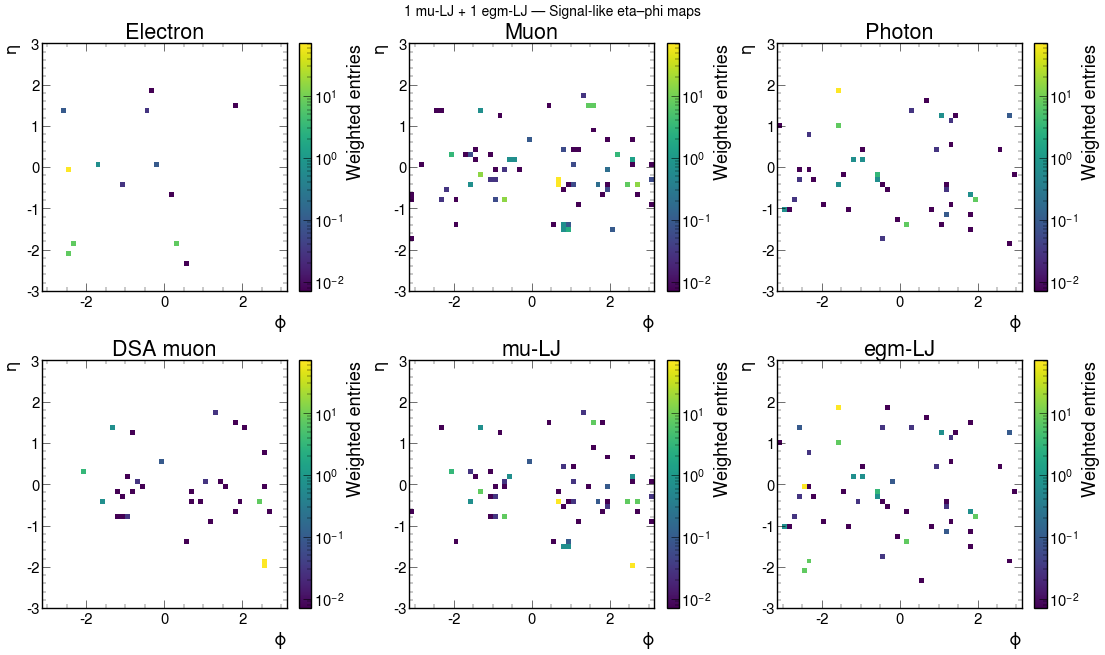

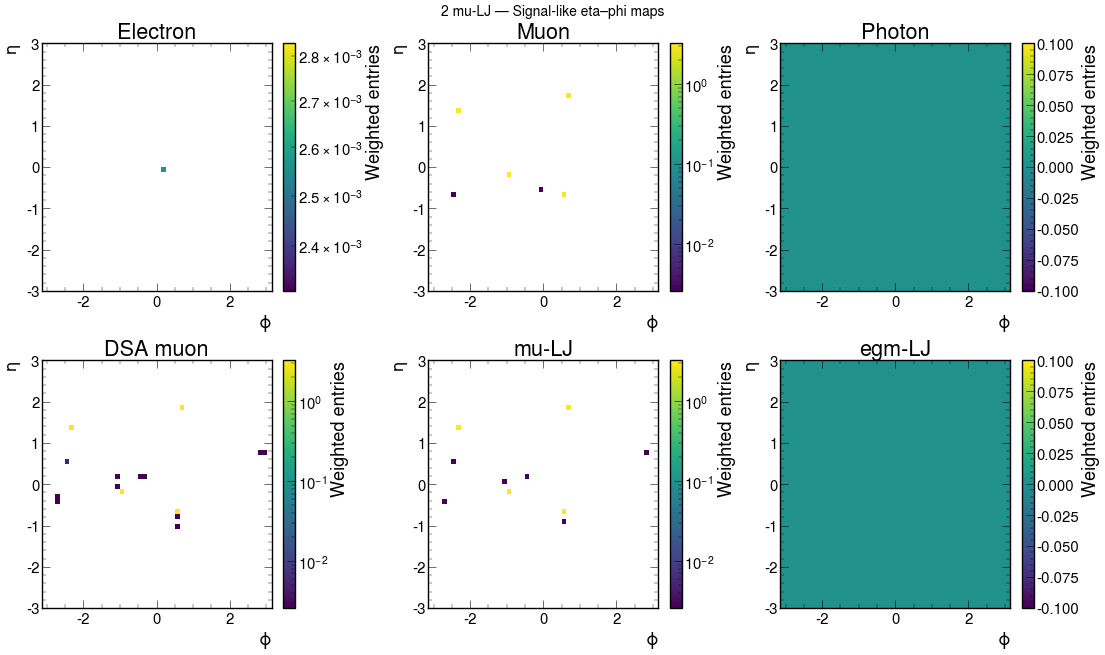

In [18]:
for channel_label in BASE_CHANNELS:
    fig, axes = plt.subplots(2, 3, figsize=(22, 13), constrained_layout=True)
    for ax, (object_label, histogram_name) in zip(axes.flat, ETA_PHI_HISTOGRAMS.items()):
        h = sum_eta_phi_histogram(SAMPLES, channel_name(channel_label, "Signal-like"), histogram_name)
        mesh, cbar_label = draw_map(ax, h, object_label, mode="yield")
        fig.colorbar(mesh, ax=ax, label=cbar_label)
    fig.suptitle(f"{channel_label} — Signal-like eta–phi maps", fontsize=20)
    plt.show(); plt.close(fig)

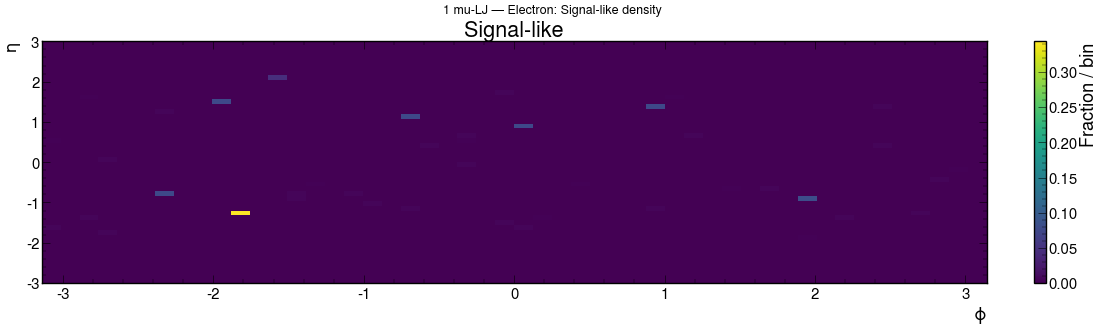

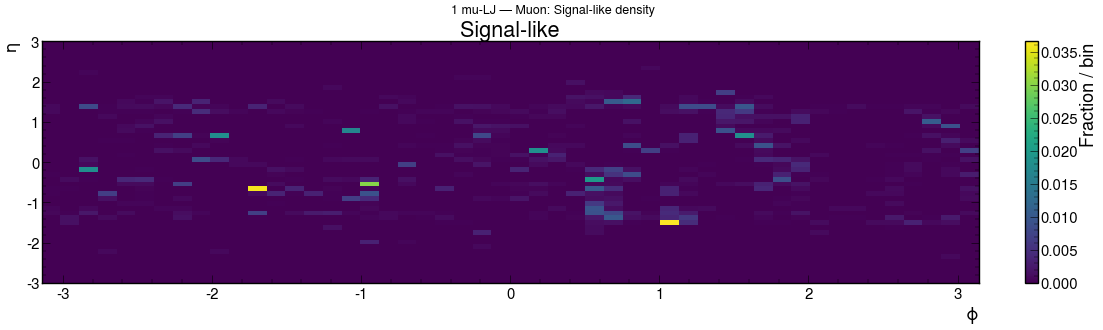

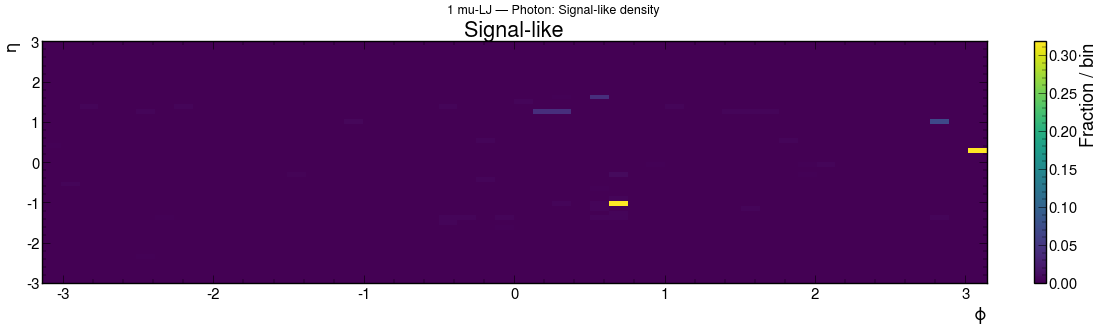

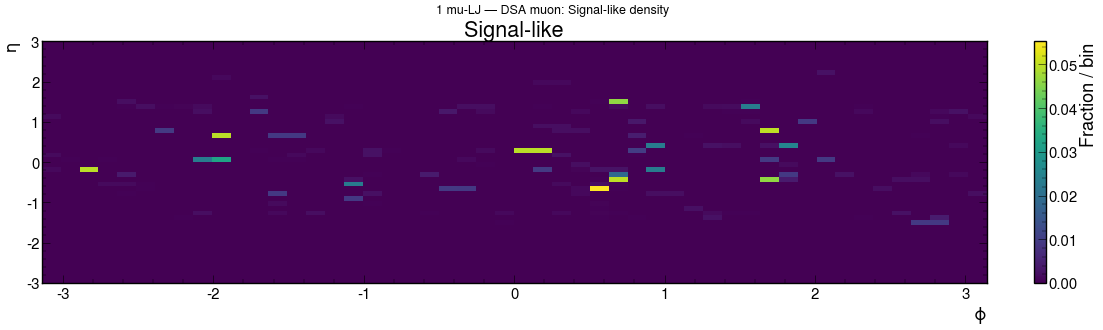

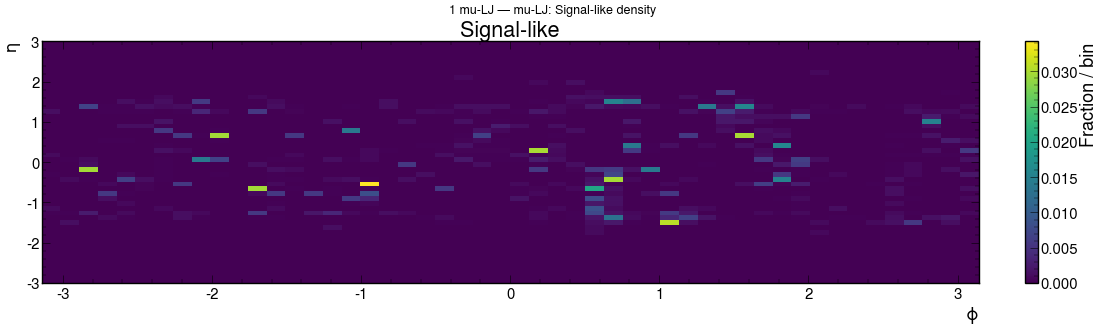

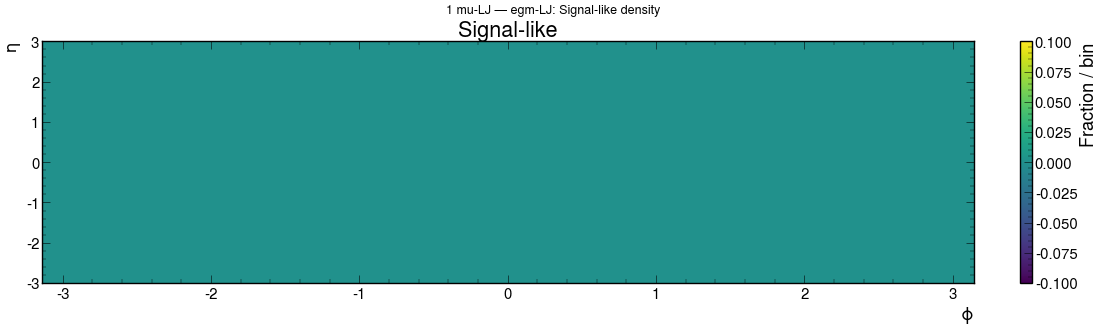

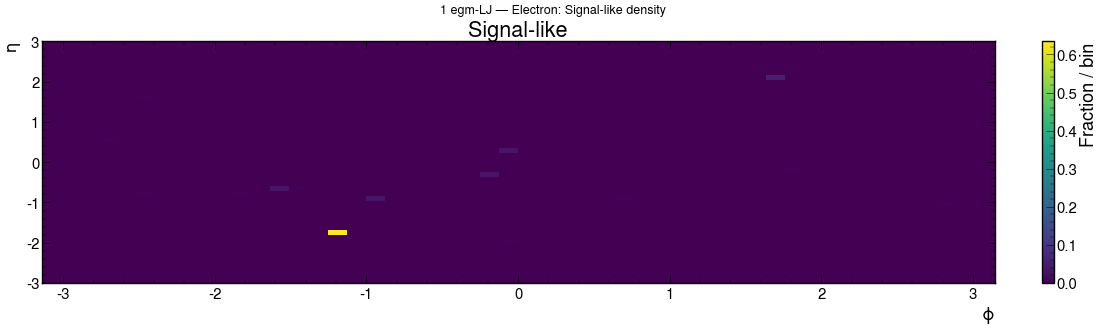

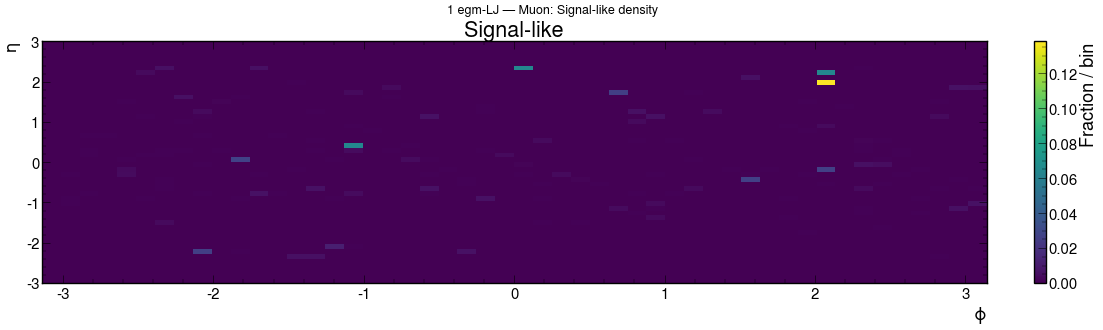

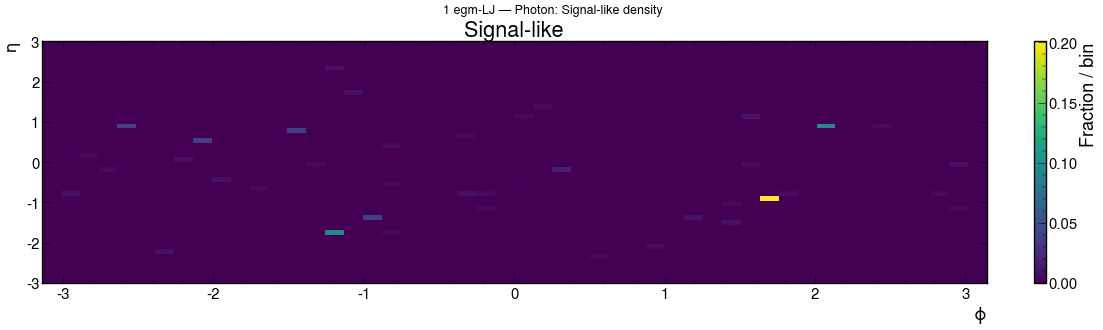

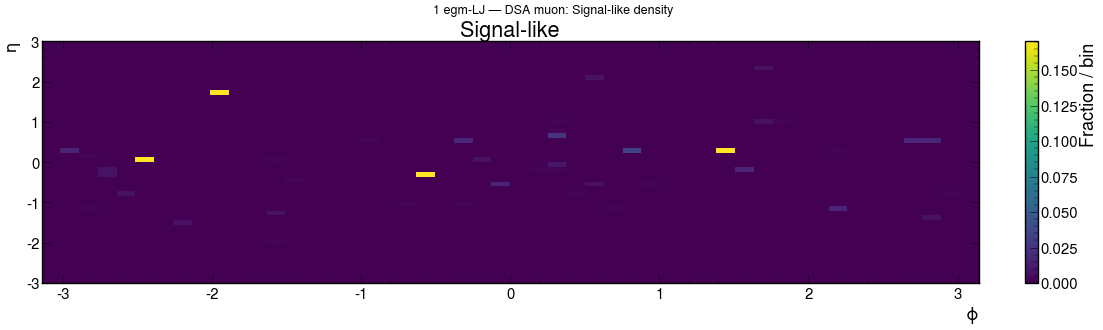

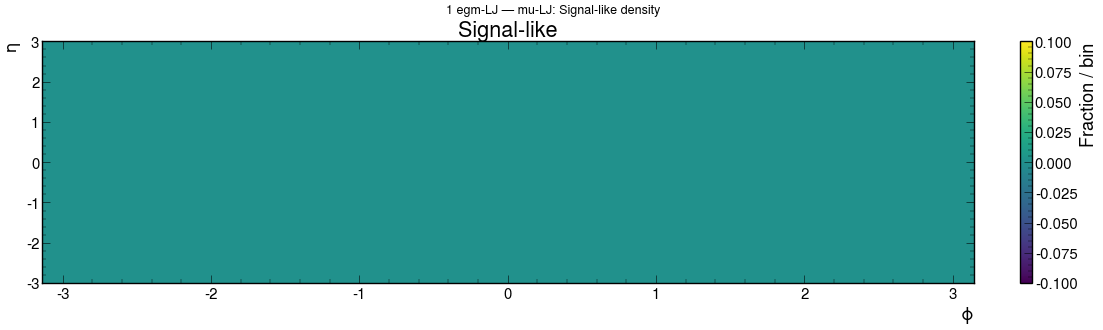

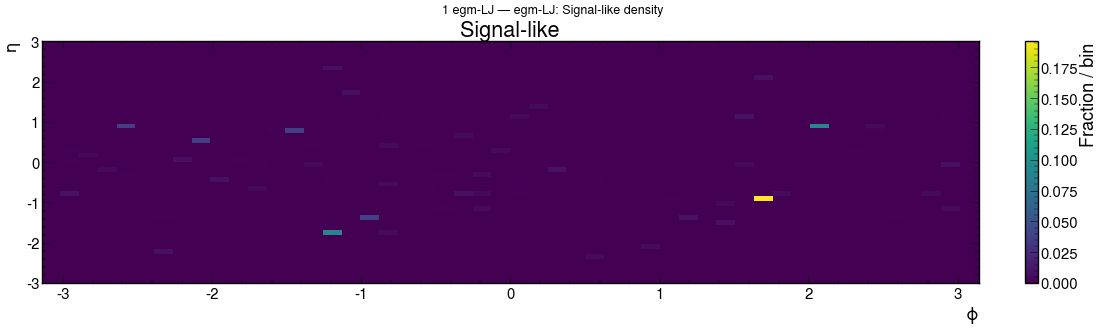

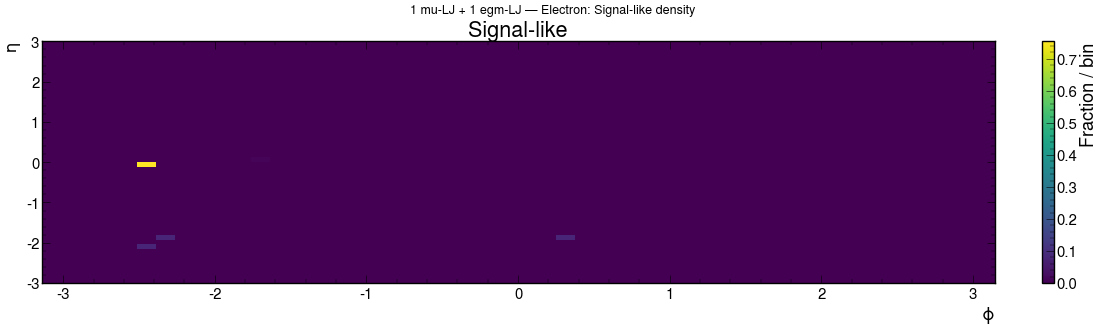

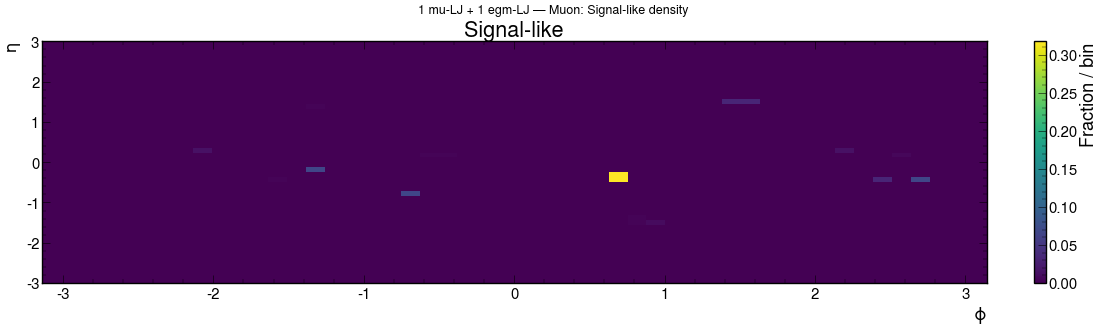

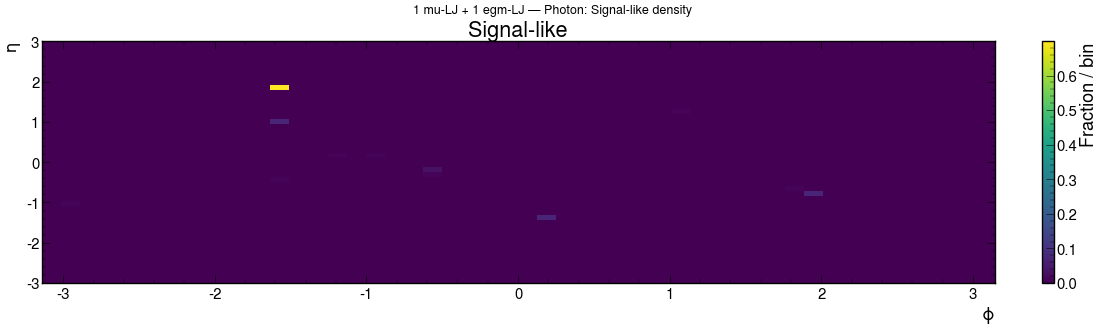

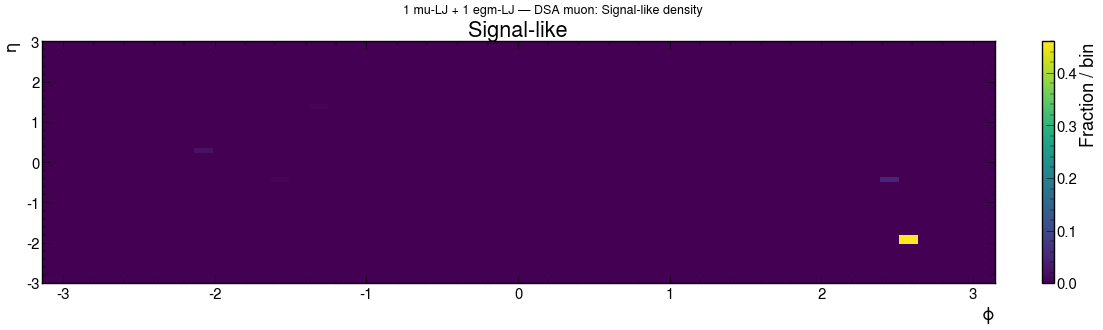

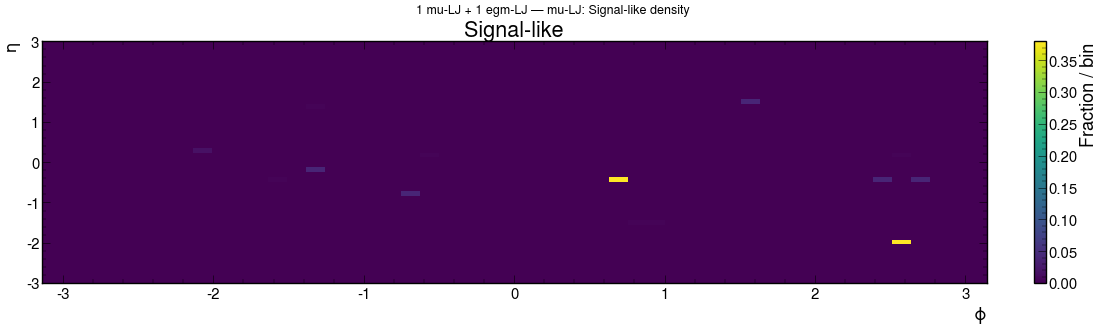

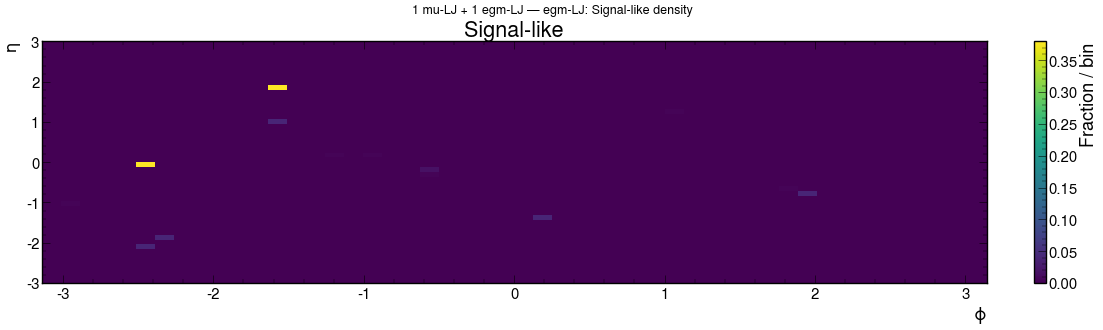

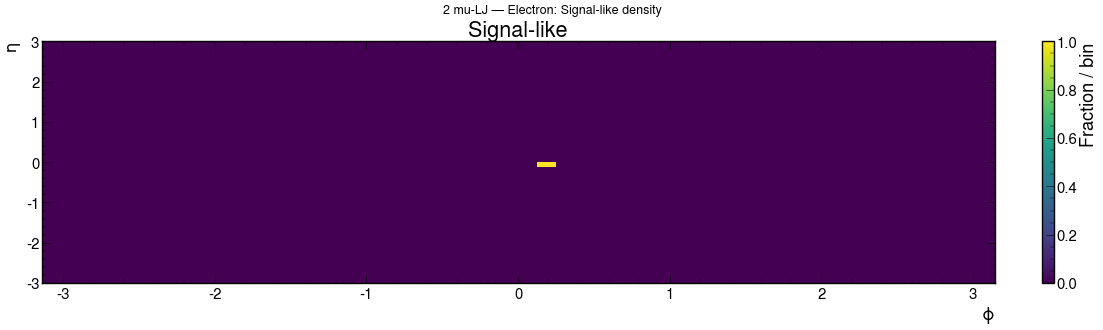

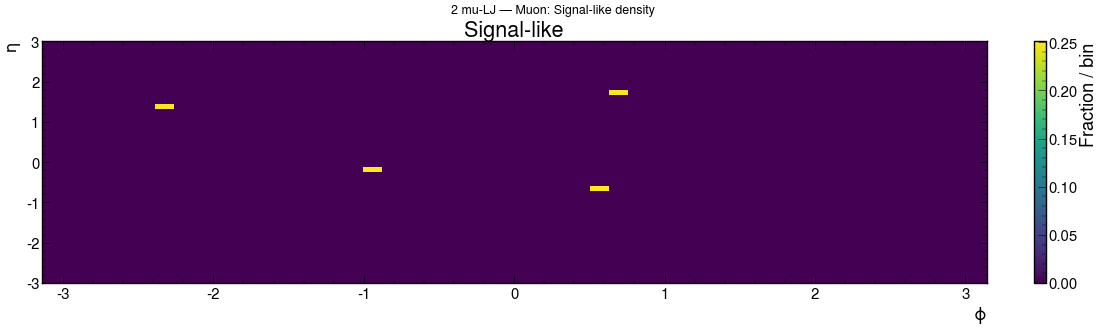

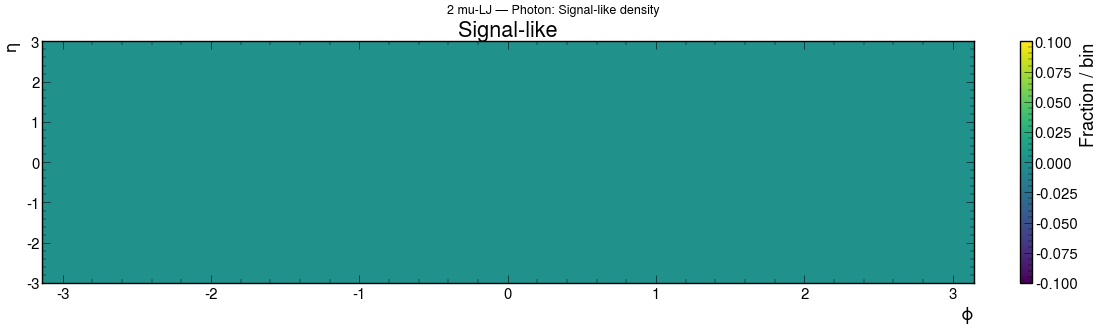

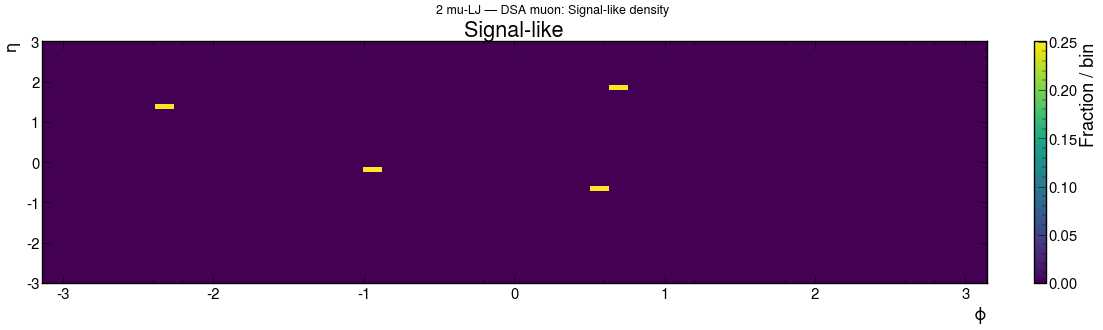

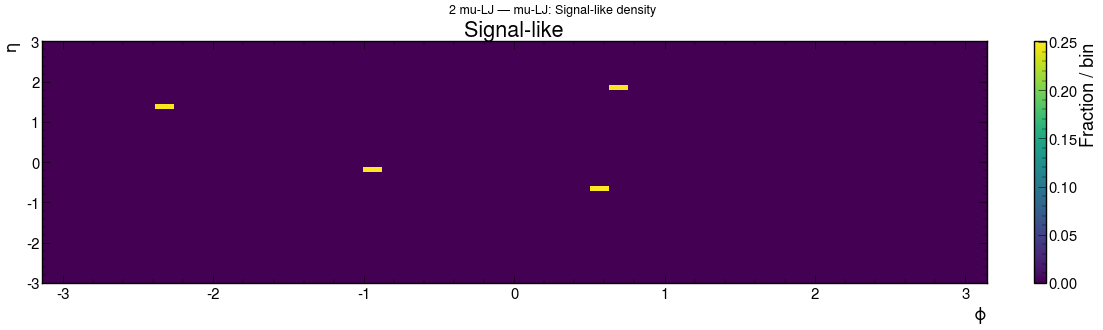

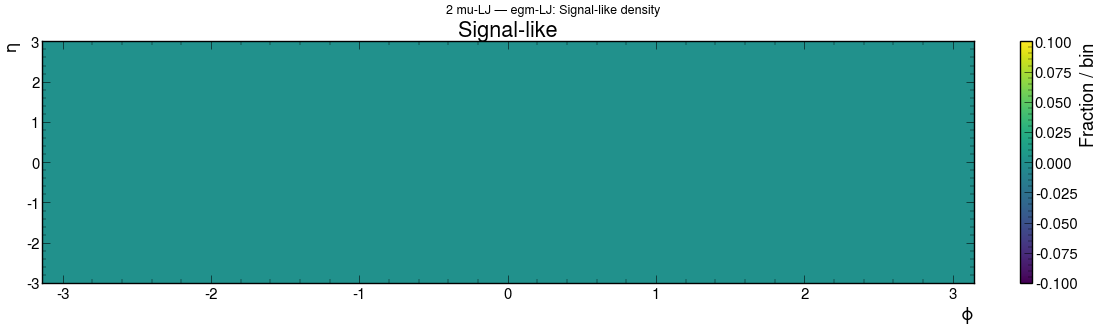

In [19]:
for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in ETA_PHI_HISTOGRAMS.items():
        fig, axes = plt.subplots(1, len(REGION_SUFFIX), figsize=(22, 6.5), constrained_layout=True)
        axes = np.atleast_1d(axes)
        for ax, region in zip(axes, REGION_SUFFIX):
            h = sum_eta_phi_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
            mesh, cbar_label = draw_map(ax, h, region, mode="density")
            fig.colorbar(mesh, ax=ax, label=cbar_label)
        fig.suptitle(f"{channel_label} — {object_label}: Signal-like density", fontsize=18)
        plt.show(); plt.close(fig)

In [20]:
occupancy_rows = []
for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in ETA_PHI_HISTOGRAMS.items():
        fractions = {}
        for region in REGION_SUFFIX:
            h = sum_eta_phi_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
            for year, spec in VETO_REGIONS.items():
                selected, error, total, fraction = region_stats(h, spec)
                fractions[(region, year)] = fraction
                occupancy_rows.append({
                    "channel": channel_label, "object": object_label, "selection": region,
                    "reference": year, "region yield": selected, "region uncertainty": error,
                    "total yield": total, "region fraction": fraction,
                })
occupancy = pd.DataFrame(occupancy_rows)
fraction_table = occupancy.pivot_table(index=["channel", "object"], columns=["reference", "selection"], values="region fraction")
display((100 * fraction_table).round(3).style.format("{:.3f}"))


## Phi projections inside the suspect eta bands

These projections directly test the reported phi bump while controlling eta. Curves are unit-normalized within the indicated eta band.

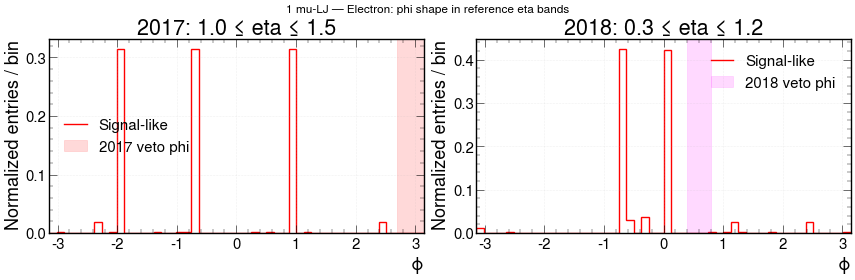

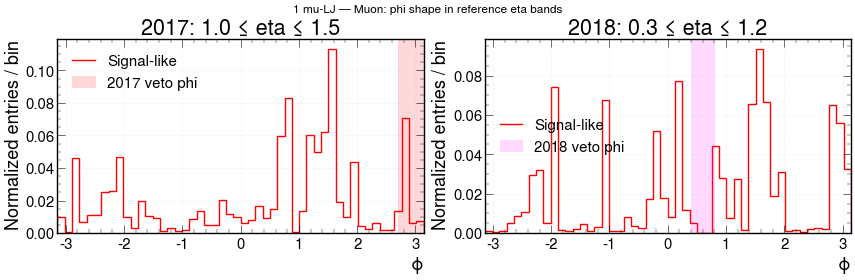

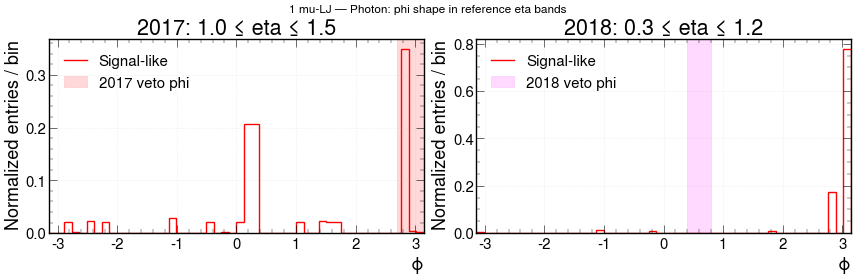

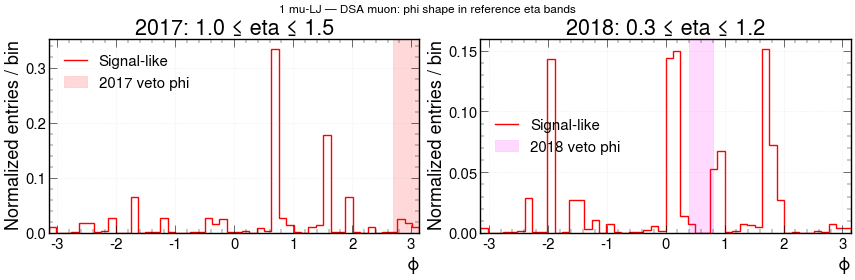

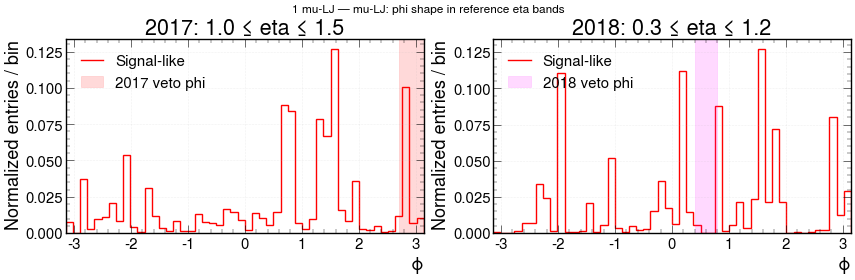

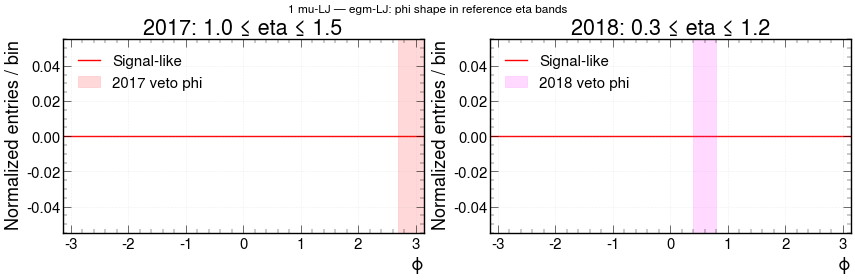

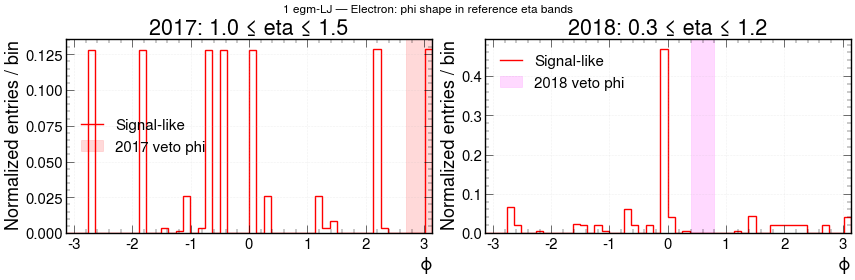

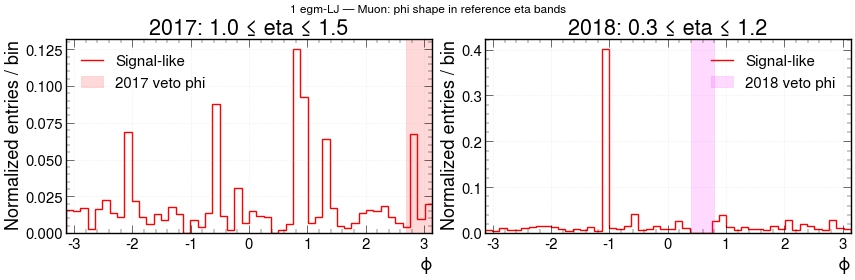

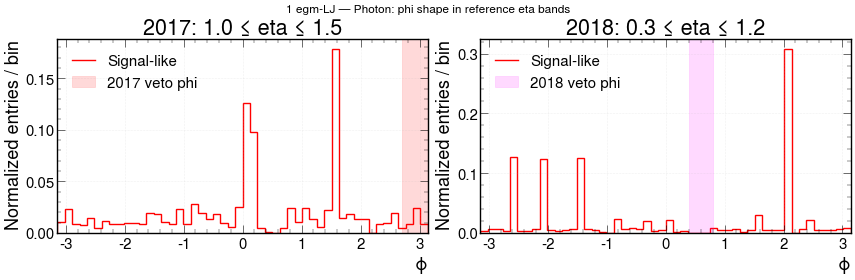

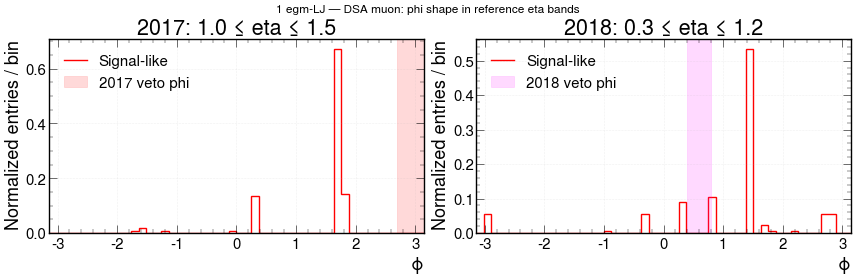

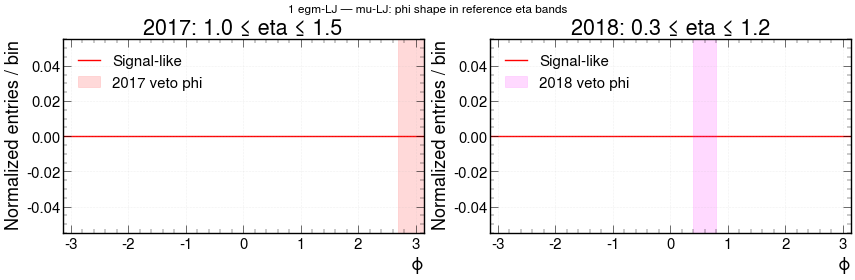

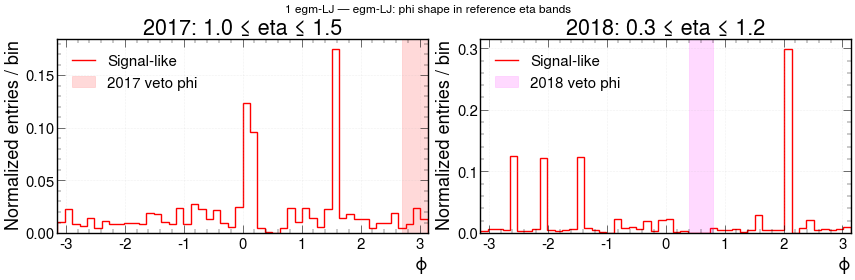

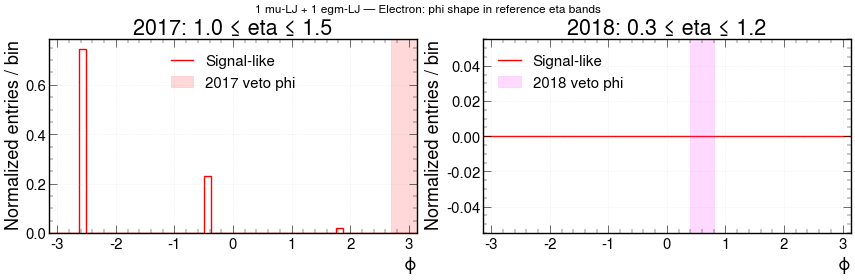

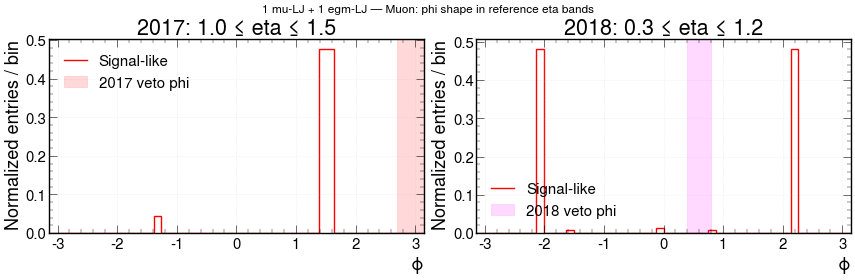

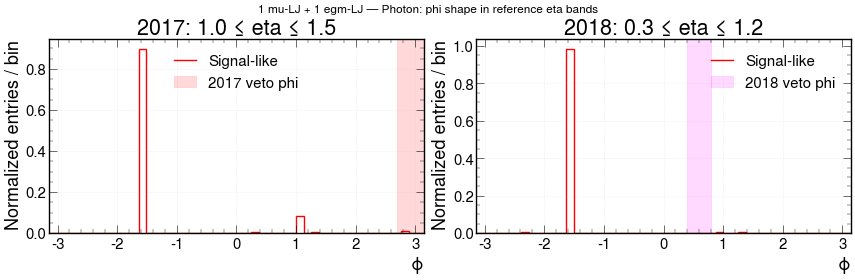

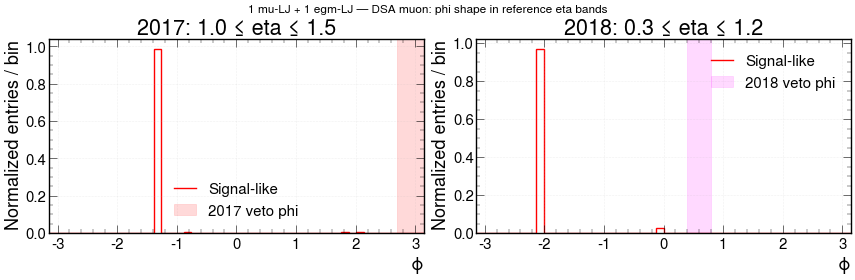

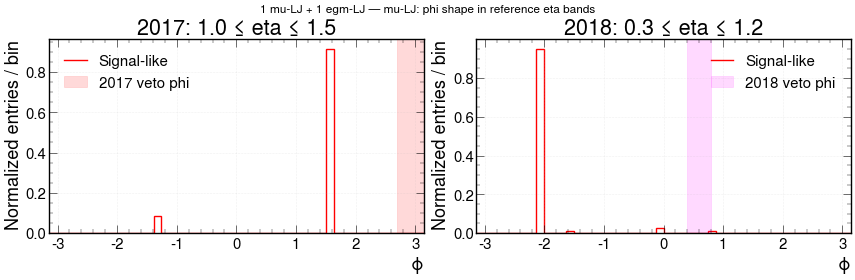

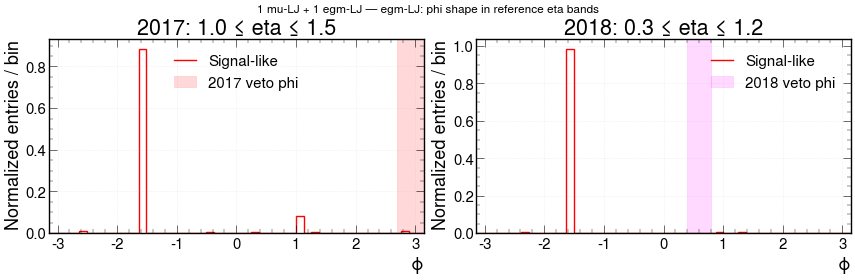

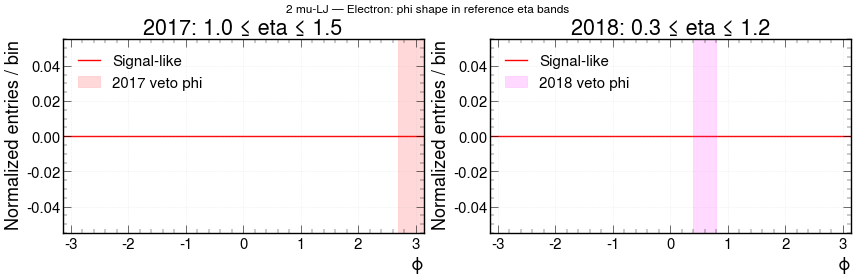

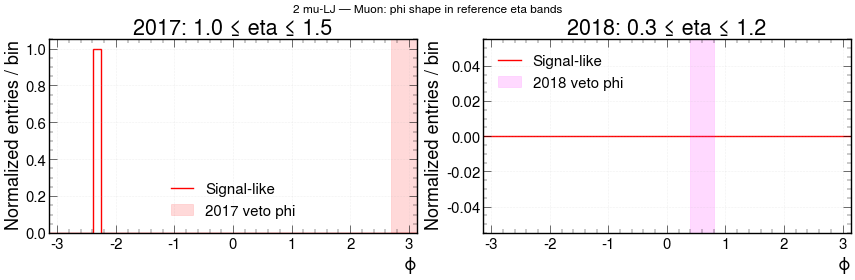

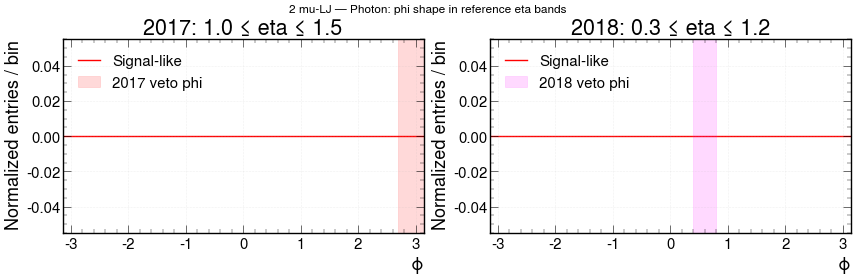

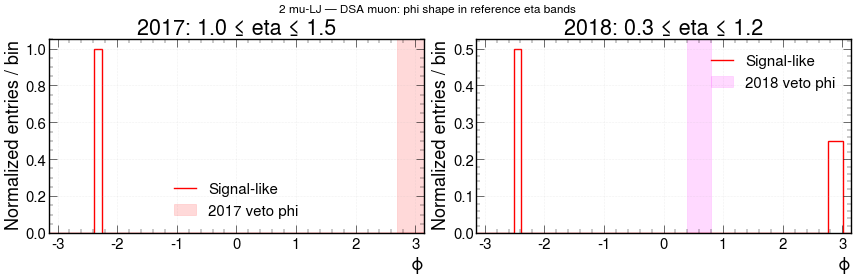

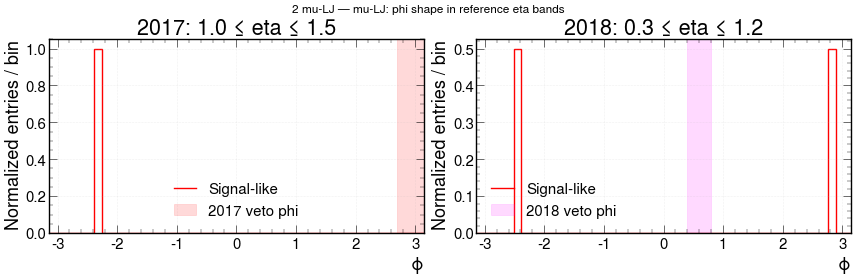

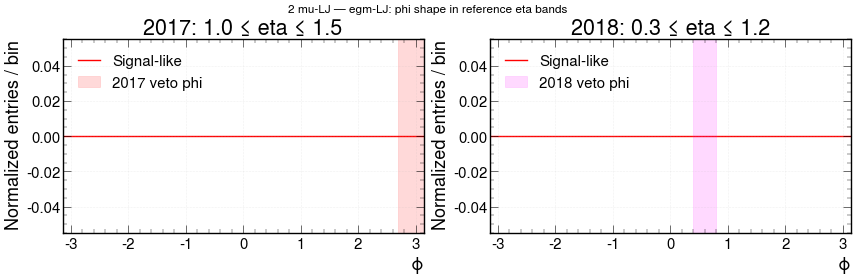

In [21]:
REGION_STYLES = {"Signal-like": ("red", "-")}
def phi_projection(histogram, eta_range):
    eta_edges, phi_edges, values, _ = eta_phi_arrays(histogram)
    eta = 0.5 * (eta_edges[:-1] + eta_edges[1:])
    selected = (eta >= eta_range[0]) & (eta <= eta_range[1])
    projection = values[selected, :].sum(axis=0)
    total = projection.sum()
    return phi_edges, projection / total if total > 0 else np.zeros_like(projection)

for channel_label in BASE_CHANNELS:
    for object_label, histogram_name in ETA_PHI_HISTOGRAMS.items():
        fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), constrained_layout=True)
        for ax, (year, spec) in zip(axes, VETO_REGIONS.items()):
            for region, (color, linestyle) in REGION_STYLES.items():
                h = sum_eta_phi_histogram(SAMPLES, channel_name(channel_label, region), histogram_name)
                edges, shape = phi_projection(h, spec["eta"])
                ax.stairs(shape, edges, color=color, linestyle=linestyle, linewidth=2, label=region)
            ax.axvspan(*spec["phi"], color=spec["color"], alpha=0.15, label=f"{year} veto phi")
            ax.set(title=f"{year}: {spec['eta'][0]} ≤ eta ≤ {spec['eta'][1]}", xlabel=r"$\phi$", ylabel="Normalized entries / bin", xlim=(-np.pi, np.pi))
            ax.grid(linestyle=":", alpha=0.35); ax.legend(frameon=False)
        fig.suptitle(f"{channel_label} — {object_label}: phi shape in reference eta bands", fontsize=17)
        plt.show(); plt.close(fig)

In [22]:
process_rows = []
for channel_label in BASE_CHANNELS:
    channel = channel_name(channel_label, "Signal-like")
    for object_label, histogram_name in ETA_PHI_HISTOGRAMS.items():
        for process, samples in BACKGROUND_GROUPS.items():
            h = sum_eta_phi_histogram(samples, channel, histogram_name)
            for year, spec in VETO_REGIONS.items():
                selected, error, total, fraction = region_stats(h, spec)
                process_rows.append({"channel": channel_label, "object": object_label,
                                     "process": process, "reference": year,
                                     "region fraction": fraction, "region yield": selected})
process_occupancy = pd.DataFrame(process_rows)
display((100 * process_occupancy.pivot_table(index=["channel", "object"], columns=["reference", "process"], values="region fraction")).round(3))

reference                     2017                         2018          \
process                         DY Diboson    QCD     TT     DY Diboson   
channel            object                                                 
1 egm-LJ           DSA muon  0.000     NaN  0.001  0.000  0.000     NaN   
                   Electron  0.000     0.0  0.000  2.381  0.000     0.0   
                   Muon      0.955     0.0  0.635  1.042  0.060     0.0   
                   Photon    1.144     0.0  0.014  0.000  0.114     0.0   
                   egm-LJ    1.120     0.0  0.014  1.010  0.112     0.0   
1 mu-LJ            DSA muon  1.639     0.0  0.791  0.000  0.364     0.0   
                   Electron  0.000     0.0  0.003  0.000  0.000     0.0   
                   Muon      2.000     0.0  1.768  0.000  0.067     0.0   
                   Photon    0.000     NaN  7.345  0.000  0.000     NaN   
                   mu-LJ     2.590     0.0  2.357  0.000  0.137     0.0   
1 mu-LJ + 1 egm-LJ DSA muon    NaN     NaN  0.000  0.000    NaN     NaN   
                   Electron    NaN     NaN  0.000    NaN    NaN     NaN   
                   Muon        NaN     NaN  0.000  0.000    NaN     NaN   
                   Photon      NaN     NaN  0.099  0.000    NaN     NaN   
                   egm-LJ      NaN     NaN  0.053  0.000    NaN     NaN   
                   mu-LJ       NaN     NaN  0.000  0.000    NaN     NaN   
2 mu-LJ            DSA muon  0.000     NaN  0.000  0.000  0.000     NaN   
                   Electron    NaN     NaN  0.000    NaN    NaN     NaN   
                   Muon      0.000     NaN  0.000  0.000  0.000     NaN   
                   mu-LJ     0.000     NaN  0.000  0.000  0.000     NaN   

reference                                  
process                        QCD     TT  
channel            object                  
1 egm-LJ           DSA muon  0.000  0.000  
                   Electron  0.000  0.000  
                   Muon      0.000  0.000  
                   Photon    0.006  0.000  
                   egm-LJ    0.006  0.000  
1 mu-LJ            DSA muon  0.250  5.263  
                   Electron  0.000  0.000  
                   Muon      0.127  1.316  
                   Photon    0.040  0.000  
                   mu-LJ     0.141  3.030  
1 mu-LJ + 1 egm-LJ DSA muon  0.000  0.000  
                   Electron  0.000    NaN  
                   Muon      0.000  0.000  
                   Photon    0.000  0.000  
                   egm-LJ    0.000  0.000  
                   mu-LJ     0.000  0.000  
2 mu-LJ            DSA muon  0.000  0.000  
                   Electron  0.000    NaN  
                   Muon      0.000  0.000  
                   mu-LJ     0.000  0.000

## Interpretation checklist

Evidence supporting the pixel-hotspot hypothesis would be: (1) a localized excess overlapping a reference rectangle, (2) a nonuniform rectangle occupancy within Signal-like, and (3) the feature appearing across more than one background process. Absence from prompt muons but presence in electrons/egm-LJs would also resemble the reference observation.

A veto should **not** be adopted from these plots alone. Confirm the feature in collision data split by year/run, inspect missing-inner-hit or valid-pixel-hit variables for objects inside and outside the rectangle, and quantify signal efficiency plus background rejection before changing the selection.

# Final summary

The tables below place the principal Signal-like 1-LJ/2-LJ yields and eta–phi reference-region fractions together for final review. Interpretation should use both normalization and shape information; a detector veto should not be inferred from MC geometry alone.

In [23]:
display(Markdown("## LJ-entry selection fractions"))
display(lj_yield_summary.round(5))
display(Markdown("## Eta-phi reference-region fractions (%)"))
display((100 * fraction_table).round(3))
display(Markdown("## Signal-like process-resolved reference-region fractions (%)"))
display((100 * process_occupancy.pivot_table(
    index=["channel", "object"],
    columns=["reference", "process"],
    values="region fraction",
)).round(3))

## LJ-entry selection fractions

signal_like_lj_entry_yield  \
channel            process                               
1 mu-LJ            Diboson                     8.63204   
                   TT                        108.03061   
                   DY                       2374.12432   
                   QCD                     95101.95828   
1 egm-LJ           Diboson                    14.15158   
                   TT                        324.09182   
                   DY                       2899.68233   
                   QCD                     11535.73319   
1 mu-LJ + 1 egm-LJ Diboson                     0.00000   
                   TT                          3.27365   
                   DY                          0.00000   
                   QCD                       182.33223   
2 mu-LJ            Diboson                     0.00000   
                   TT                          6.54731   
                   DY                          6.49608   
                   QCD                         0.01543   

                            signal_like_uncertainty  
channel            process                           
1 mu-LJ            Diboson                  1.64523  
                   TT                      18.80572  
                   DY                     101.67230  
                   QCD                   9856.50478  
1 egm-LJ           Diboson                  2.01962  
                   TT                      32.57245  
                   DY                     102.43319  
                   QCD                   3652.39623  
1 mu-LJ + 1 egm-LJ Diboson                  0.00000  
                   TT                       3.27365  
                   DY                       0.00000  
                   QCD                    101.05079  
2 mu-LJ            Diboson                  0.00000  
                   TT                       4.62965  
                   DY                       4.59342  
                   QCD                      0.00630

## Eta-phi reference-region fractions (%)

reference                          2017        2018
selection                   Signal-like Signal-like
channel            object                          
1 egm-LJ           DSA muon       0.001       0.000
                   Electron       0.156       0.000
                   Muon           0.730       0.016
                   Photon         0.236       0.027
                   egm-LJ         0.253       0.026
1 mu-LJ            DSA muon       0.816       0.259
                   Electron       0.003       0.000
                   Muon           1.772       0.127
                   Photon         7.163       0.039
                   mu-LJ          2.360       0.144
1 mu-LJ + 1 egm-LJ DSA muon       0.000       0.000
                   Electron       0.000       0.000
                   Muon           0.000       0.000
                   Photon         0.095       0.000
                   egm-LJ         0.052       0.000
                   mu-LJ          0.000       0.000
2 mu-LJ            DSA muon       0.000       0.000
                   Electron       0.000       0.000
                   Muon           0.000       0.000
                   mu-LJ          0.000       0.000

## Signal-like process-resolved reference-region fractions (%)

reference                     2017                         2018          \
process                         DY Diboson    QCD     TT     DY Diboson   
channel            object                                                 
1 egm-LJ           DSA muon  0.000     NaN  0.001  0.000  0.000     NaN   
                   Electron  0.000     0.0  0.000  2.381  0.000     0.0   
                   Muon      0.955     0.0  0.635  1.042  0.060     0.0   
                   Photon    1.144     0.0  0.014  0.000  0.114     0.0   
                   egm-LJ    1.120     0.0  0.014  1.010  0.112     0.0   
1 mu-LJ            DSA muon  1.639     0.0  0.791  0.000  0.364     0.0   
                   Electron  0.000     0.0  0.003  0.000  0.000     0.0   
                   Muon      2.000     0.0  1.768  0.000  0.067     0.0   
                   Photon    0.000     NaN  7.345  0.000  0.000     NaN   
                   mu-LJ     2.590     0.0  2.357  0.000  0.137     0.0   
1 mu-LJ + 1 egm-LJ DSA muon    NaN     NaN  0.000  0.000    NaN     NaN   
                   Electron    NaN     NaN  0.000    NaN    NaN     NaN   
                   Muon        NaN     NaN  0.000  0.000    NaN     NaN   
                   Photon      NaN     NaN  0.099  0.000    NaN     NaN   
                   egm-LJ      NaN     NaN  0.053  0.000    NaN     NaN   
                   mu-LJ       NaN     NaN  0.000  0.000    NaN     NaN   
2 mu-LJ            DSA muon  0.000     NaN  0.000  0.000  0.000     NaN   
                   Electron    NaN     NaN  0.000    NaN    NaN     NaN   
                   Muon      0.000     NaN  0.000  0.000  0.000     NaN   
                   mu-LJ     0.000     NaN  0.000  0.000  0.000     NaN   

reference                                  
process                        QCD     TT  
channel            object                  
1 egm-LJ           DSA muon  0.000  0.000  
                   Electron  0.000  0.000  
                   Muon      0.000  0.000  
                   Photon    0.006  0.000  
                   egm-LJ    0.006  0.000  
1 mu-LJ            DSA muon  0.250  5.263  
                   Electron  0.000  0.000  
                   Muon      0.127  1.316  
                   Photon    0.040  0.000  
                   mu-LJ     0.141  3.030  
1 mu-LJ + 1 egm-LJ DSA muon  0.000  0.000  
                   Electron  0.000    NaN  
                   Muon      0.000  0.000  
                   Photon    0.000  0.000  
                   egm-LJ    0.000  0.000  
                   mu-LJ     0.000  0.000  
2 mu-LJ            DSA muon  0.000  0.000  
                   Electron  0.000    NaN  
                   Muon      0.000  0.000  
                   mu-LJ     0.000  0.000